In [6]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os
# adding path to folder
sys.path.insert(0, '../tools/')
from utils import ParticleCode, load_dataset
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match

import matplotlib.pyplot as plt
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True
import matplotlib.colors as mcolors  # Importing the correct module for colors
import plotly.graph_objects as go


pdg_tab = ParticleCode()

In [7]:
# Load PDG Codes
pdg_tab = ParticleCode()

plot_dir = './plots-gk/'
# Load datasets 
n_files = 998
location = "nersc"
df=load_dataset(n_files,'nersc')
caf_reader = CafReader(df)

Openning MiniRun 5 beta 2.a CAFs
Reading  998  files


0it [00:00, ?it/s]

877it [16:45,  1.15s/it]


In [8]:
#dimensions of the detector
anode_xs = np.array([-63.931, -3.069, 3.069, 63.931])
anode_ys = np.array([-19.8543, 103.8543]) - 42  # Subtract 42 from all y coordinates
anode_zs = np.array([-64.3163, -2.6837, 2.6837, 64.3163])
#Fiducial Volume
tpc_dist = 8.0
xbound = 63.931
ybound = 62.076
zbound = 64.3163


In [9]:
#find if an interaction is contained in FV
def isContainedFV(vx,vy,vz):
    tpc_dist = 10.0
    xbound = 63.931
    ybound = 62.076
    zbound = 64.3163

    if(
        abs(vx)<xbound-tpc_dist and
        abs(vx)>tpc_dist and
        abs(vy)<ybound-tpc_dist and
        abs(vz)>tpc_dist and
        abs(vz)<zbound-tpc_dist
    ): 
        return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

#TRUE: filter the true ccmunu fv signal to tracks that exit 2x2 downstream
def find_end_muon(ev_data, mask_signal):
    muon_out = np.zeros_like(mask_signal, dtype=bool)
    for vtx, value in enumerate(mask_signal):
        if value:
            n_tracks = ev_data['rec.mc.nu.prim..length'][vtx]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx]) if vtx > 0 else 0
            
            # Scan over particles associated with this interaction
            for ip in range(n_pre, n_pre + n_tracks):
                if (ev_data['rec.mc.nu.prim.end_pos.z'][ip]>=zbound)&(mask_signal[vtx]==1):
                    muon_out[vtx] = True 
                    break  # No need to check further if a match is found
    return muon_out
   

In [10]:
#this gather TRUE INFO neutron induced proton info, neutrons percents in the signal, etc
num_neutrinos_total = 0
num_prim_neutrons_total =0 #num of primary neutrons in the simulation
num_neutrons_fv=0  #num of neutrons in the fiducial volume
num_neutrons_dv = 0 #num of neutrons in the detector
num_neutrons_signal =0 #num of neutrons on the signal: cc numu Ar fd
num_out_muon =0 

#store energies 
E_neutrino_all = []
E_neutrino_Ar = [] #store neutrino energy within FV with Ar
E_neutrino_dv_Ar = [] #store neutrino energy within detector with Ar
E_neutrino_fv_Ar = [] #store neutrino energy within FV with Ar
E_neutrino_signal = [] #store neutrino energy of signal ccnumu FV Ar
E_neutrino_w_prim_neutrons = [] #store neutrino energies of int that produced primary neutrons
E_prim_neutrons_signal = [] #store energies of the primary neutrons in the signal
E_neutron_parents = [] #store energy of the neutrons that are proton parents
E_neutrino_n_p = [] #store neutrino energy of the interactions that produced n->p
E_proton =[] #store energy of neutron induced protonse

#store proton tracks info
track_vtx_distances = [] #distance of the proton track to the vertex
track_lengths= [] #proton track lenght 
track_lengths2= []
track_vtx_distances2=[]
# Create lists to store the vertex positions of vtx that happen in FV
vertices_x = []
vertices_y = []
vertices_z = []

#store vertices of the signal that exit 2x2 downstream
vx_t=[]
vy_t=[]
vz_t=[]


for event in range(len(df)):

    ev_data= df.iloc[event]

    #Mask vertex on the detector volume
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )

    vertices_x.extend(ev_data['rec.mc.nu.vtx.x'][mask_signal])
    vertices_y.extend(ev_data['rec.mc.nu.vtx.y'][mask_signal])
    vertices_z.extend(ev_data['rec.mc.nu.vtx.z'][mask_signal])

    #some data we can gather directly:
    n_vtx = len(ev_data['rec.mc.nu.E']) 
    E_neutrino_all.extend(ev_data['rec.mc.nu.E'])
    num_neutrinos_total +=  ev_data['rec.mc.nu..length']
    E_neutrino_Ar.extend(ev_data['rec.mc.nu.E'][(ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)])
    E_neutrino_dv_Ar.extend(ev_data['rec.mc.nu.E'][mask_dv_Ar]) 
    E_neutrino_fv_Ar.extend(ev_data['rec.mc.nu.E'][mask_fv_Ar])  
    E_neutrino_signal.extend(ev_data['rec.mc.nu.E'][mask_signal]) #ccmunu df
    num_prim_neutrons_total += sum(ev_data['rec.mc.nu.nneutron']) #this is only primaries
    num_neutrons_dv += sum(ev_data['rec.mc.nu.nneutron'][mask_dv])
    num_neutrons_fv += sum(ev_data['rec.mc.nu.nneutron'][mask_fv])
    num_neutrons_signal += sum(ev_data['rec.mc.nu.nneutron'][mask_signal])

    signal_out_muon = find_end_muon(ev_data, mask_signal)
    num_out_muon += np.sum(signal_out_muon)

    vx_t.extend(ev_data['rec.mc.nu.vtx.x'][signal_out_muon])
    vy_t.extend(ev_data['rec.mc.nu.vtx.y'][signal_out_muon])
    vz_t.extend(ev_data['rec.mc.nu.vtx.z'][signal_out_muon])

    #now let's gather the data from neutrons that produced protons

    for vtx in range(n_vtx):  # Using num interactions directly as the range
    
        #if vtx it is not in the signal, skip vtx
        if (mask_signal[vtx]==False):
            continue
        else:
            #now check for neutrons with proton daughter 
            #a vtx can produce several neutrons, we need to ensure we include the vtx info only one time 
            #E.g. an vtx might have more than one neutron, but it's still same vtx.
            tracked_neutron_ids = set() #track the vtx that we already count
            n_prim = ev_data['rec.mc.nu.prim..length'][vtx] #num of total prim
            n_sec = ev_data['rec.mc.nu.sec..length'][vtx]   #num of total sec


            #Luis's trick to iterate between primaries/sec per vtx
            if vtx == 0:
                n_pred_prim = 0
                n_pred_sec = 0
            else:
                n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx])
                n_pred_sec = np.sum(ev_data['rec.mc.nu.sec..length'][:vtx])

            #false if you haven't included that vtx, if a neutrons is found then True
            included_vertex=False  
            included_vertex_np = False  #to count neutrons that produced protons

            #iterates over all primaries of the interaction. 
            # This finds info from primary neutrons
            for ip in range(n_pred_prim, n_pred_prim + n_prim):
                if (ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron):
                    #Store energy of primary neutrons. Sanity-check: length must match num_prim_neutrons_signal
                    E_prim_neutrons_signal.append(ev_data['rec.mc.nu.prim.p.E'][ip])              
                    #save the neutrino energy of the vtx that produced at least one prim neutron
                    if included_vertex == False: 
                        E_neutrino_w_prim_neutrons.extend(ev_data['rec.mc.nu.E'][mask_signal])
                        included_vertex= True  #make true so we don't overcount the interactions/vertex
                    else: pass  #skip vtx if you already included it 

            # iterate over secondary particles to find neutron-induced protons
            for isec in range(n_pred_sec, n_pred_sec + n_sec):
                # check if any of the secondary particles are protons
                if ev_data['rec.mc.nu.sec.pdg'][isec] == pdg_tab.proton:
                    # if proton, save the G4 ID of the parent
                    proton_parent_id = ev_data['rec.mc.nu.sec.parent'][isec]
                    # iterate over primary particles to find parent 
                    for ip in range(n_pred_prim, n_pred_prim + n_prim):
                        if (
                            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
                            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
                        ):
                            # This interaction has a proton produced by a neutron
                            if included_vertex_np == False:
                                E_neutrino_n_p.extend(ev_data['rec.mc.nu.E'][mask_signal]) #save energy of the interaction
                                included_vertex_np= True #make true so we don't overcount the interactions/vertex
                            else: pass #skip vtx if you already included it 

                            if proton_parent_id not in tracked_neutron_ids:
                                #vtx_n_p[vtx] = True
                                #get energies and calculate distance to vertex
                                E_neutron_parents.append(ev_data['rec.mc.nu.prim.p.E'][ip])
                                E_proton.append(ev_data['rec.mc.nu.sec.p.E'][isec])
                                tracked_neutron_ids.add(proton_parent_id)
                                #proton distance to vertex

                                track_length, vtx_distance = calculate_track_properties(
                                (ev_data['rec.mc.nu.sec.start_pos.x'][isec], ev_data['rec.mc.nu.sec.start_pos.y'][isec], ev_data['rec.mc.nu.sec.start_pos.z'][isec]),
                                (ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec]),
                                (ev_data['rec.mc.nu.vtx.x'][vtx], ev_data['rec.mc.nu.vtx.y'][vtx], ev_data['rec.mc.nu.vtx.z'][vtx])
                                )
                                track_lengths.append(track_length)
                                track_vtx_distances.append(vtx_distance)

In [11]:

print(f'There are {num_prim_neutrons_total} primary neutrons in the simulation')
print(f'There are {num_neutrons_dv} prim neutrons in the DV, {num_neutrons_fv} in the FV, and  {num_neutrons_signal} in the signal')
print(f'There are {len(E_neutrino_w_prim_neutrons)} interactions in the signal that produced prim neutrons')
print(f'There are {len(E_proton)} neutron induced protons and {len(E_neutrino_n_p )} n->p interactions  ')
print(f'There are {len(vertices_x)} vertices in FV')

There are 1488195 primary neutrons in the simulation
There are 56245 prim neutrons in the DV, 27337 in the FV, and  20257 in the signal
There are 7185 interactions in the signal that produced prim neutrons
There are 2023 neutron induced protons and 1911 n->p interactions  
There are 8302 vertices in FV


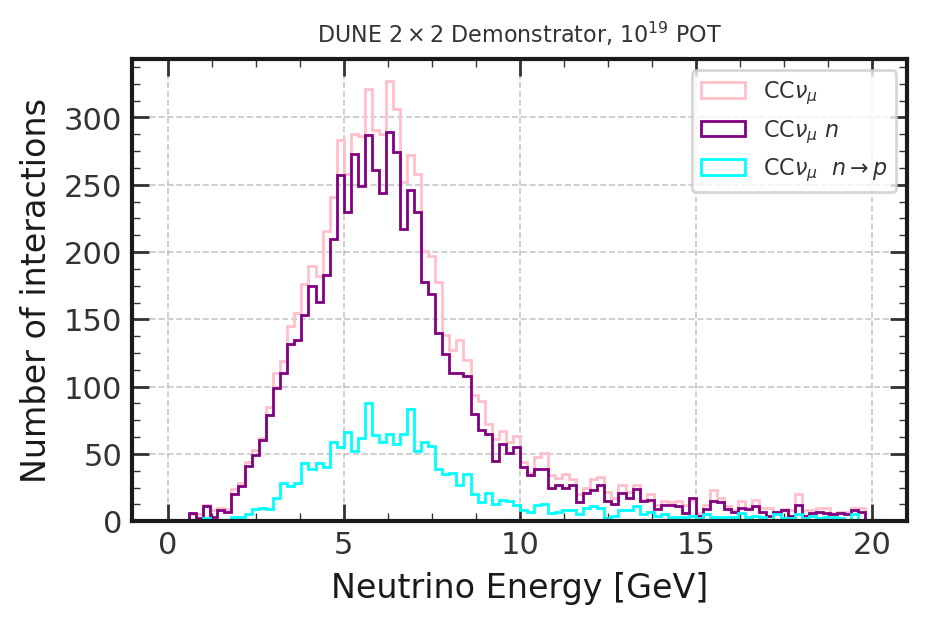

In [12]:

plt.hist(E_neutrino_signal,bins=100,histtype='step',range=(0,20), color='pink', label=r'CC$\nu_\mu$')
plt.hist(E_neutrino_w_prim_neutrons,bins=100,histtype='step',range=(0,20), color='purple', label=r'CC$\nu_\mu$ $n$')
plt.hist(E_neutrino_n_p,bins=100,histtype='step',range=(0,20), color='cyan', label=r'CC$\nu_\mu$  $n\rightarrow p$')
plt.ylabel('Number of interactions')
plt.xlabel('Neutrino Energy [GeV]')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '8')
plt.legend(fontsize='8')
#plt.yscale('log')
plt.show()

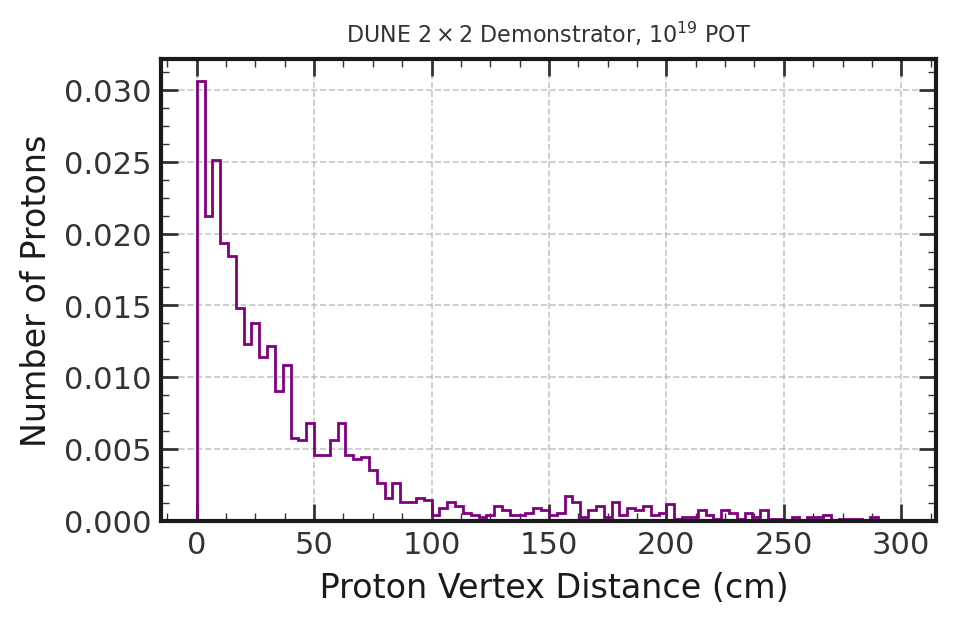

2023

In [13]:
plt.hist(track_vtx_distances,bins=90,histtype='step',range=[0,300], color='purple', density=True,label=r'p')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '8')
plt.xlabel(' Proton Vertex Distance (cm)')
plt.ylabel('Number of Protons')
#plt.yscale('log')
plt.show()

len(track_vtx_distances)

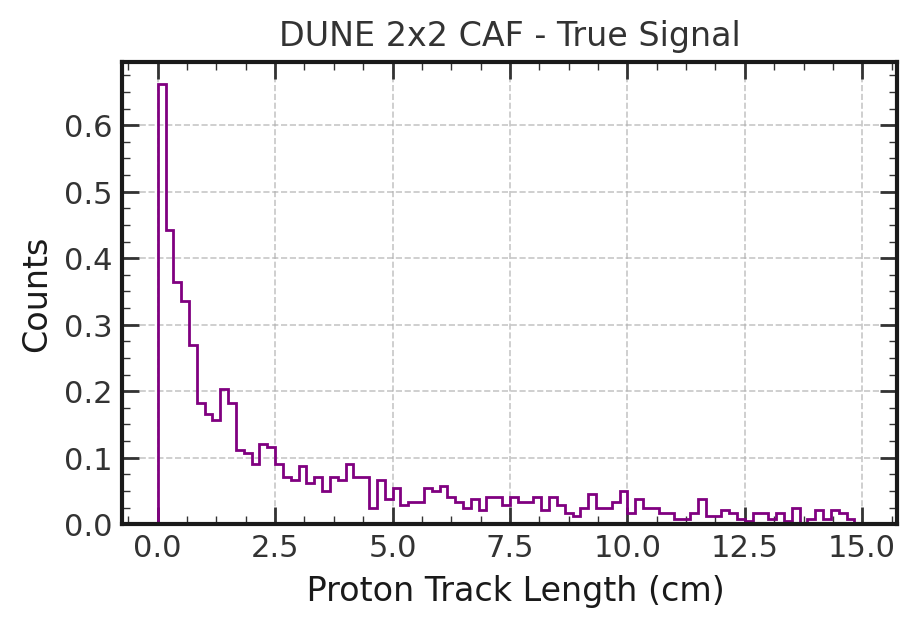

In [14]:
plt.hist(track_lengths,bins=90,histtype='step',range=[0,15], color='purple', density=True,label=r'p')
plt.title('DUNE 2x2 CAF - True Signal')
plt.xlabel(' Proton Track Length (cm)')
plt.ylabel('Counts')
#plt.yscale('log')
plt.show()

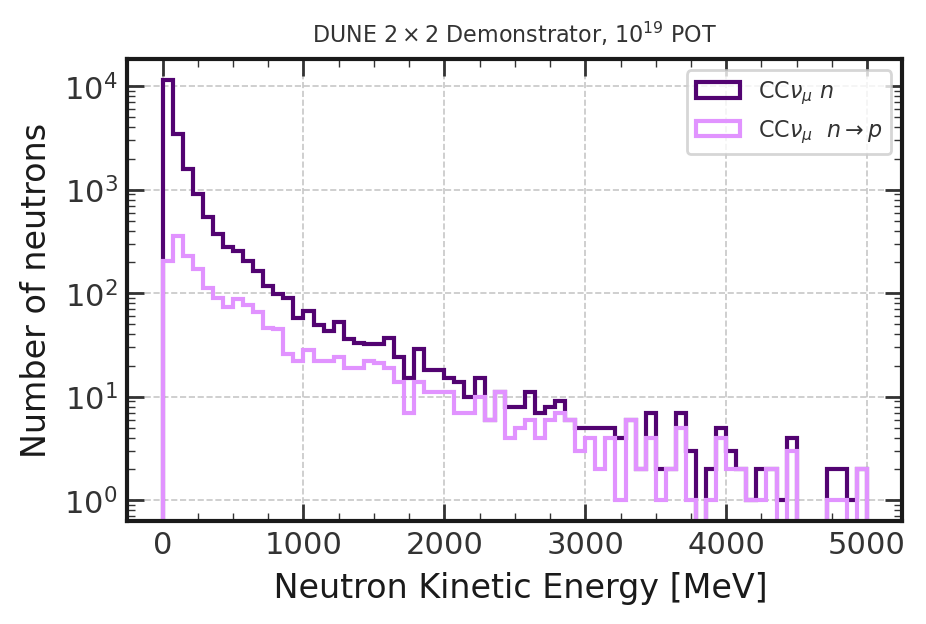

In [15]:
K_neutron_parents1 = [x - pdg_tab.neutron_mass/1000 for x in E_neutron_parents]
K_neutron_prim1 =[x - pdg_tab.neutron_mass/1000 for x in E_prim_neutrons_signal ]
K_neutron_parents = [x*1000 for x in K_neutron_parents1]
K_neutron_prim =[x*1000 for x in K_neutron_prim1 ]

plt.hist(K_neutron_prim,bins=70,histtype='step', color='#520371', linewidth=1.5,range= [0,5000], label=r'CC$\nu_\mu$ $n$')
plt.hist(K_neutron_parents,bins=70,histtype='step', color='#e193ff',  linewidth=1.5,range= [0,5000],  label=r'CC$\nu_\mu$  $n\rightarrow p$')
plt.ylabel('Number of neutrons')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '8')
plt.legend(fontsize='8')
plt.xlabel(' Neutron Kinetic Energy [MeV]')
plt.yscale('log')
plt.show()

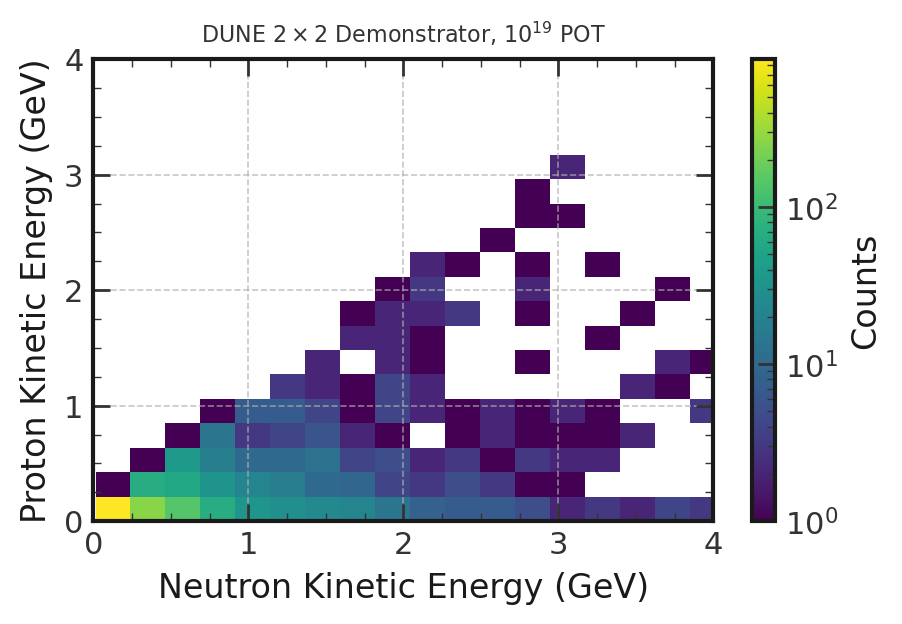

In [16]:
K_neutron= [x - pdg_tab.neutron_mass/1000 for x in E_neutron_parents]
K_proton =[x - pdg_tab.proton_mass/1000 for x in E_proton ]


plt.hist2d(K_neutron, K_proton, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.colorbar(label='Counts')
plt.xlabel('Neutron Kinetic Energy (GeV)')
plt.ylabel('Proton Kinetic Energy (GeV)')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '8')
#plt.legend(fontsize='8')
plt.show()

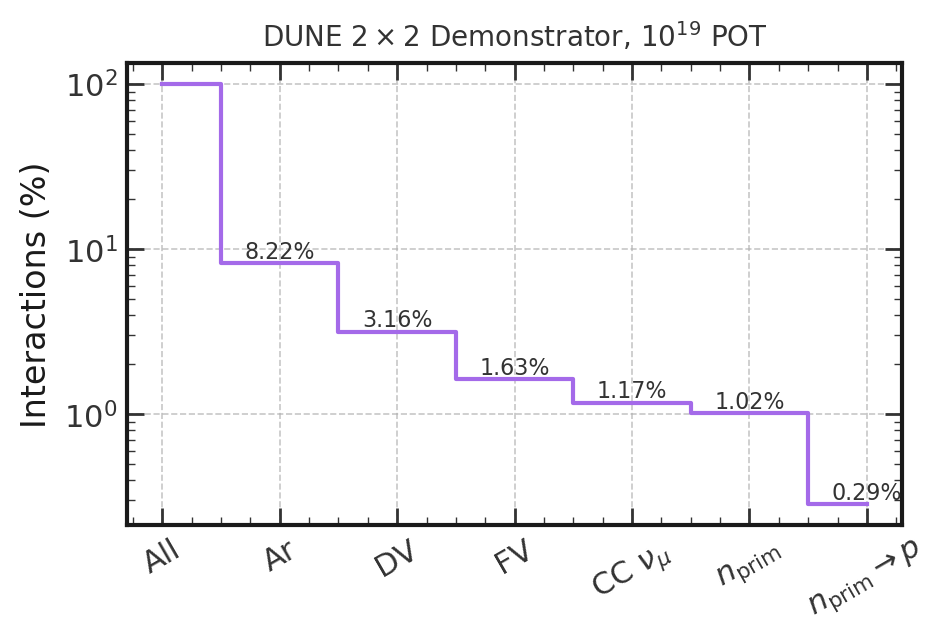

,Cut,Interactions,Percent (%)
0,Total Simulation,707631,100.00
1,neutrino-Argon,58188,8.22
2,Detector Volume,22353,3.16
3,Fiducial Volume (FV),11516,1.63
4,CC muon neutrino,8302,1.17
5,Primary Neutrons,7185,1.02
6,Neutron Induced Proton,2023,0.29


In [17]:
# Data and positions
portions = [(num_neutrinos_total), len(E_neutrino_Ar), len(E_neutrino_dv_Ar), len(E_neutrino_fv_Ar), len(E_neutrino_signal), len(E_neutrino_w_prim_neutrons), len(E_neutron_parents ) ]/(0.01*num_neutrinos_total)
positions = [0,1,2,3,4,5,6]
# Plot
plt.step(positions, portions, where='mid', color='#a46ae9', label='Data Line')
plt.yscale('log')
plt.xticks(positions,[r'All',r'Ar', r'DV', r'FV', r'CC $\nu_{\mu}$', r'$n_{\text{prim}}$', r'$n_{\text{prim}} \rightarrow p$'],rotation=30)
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.ylabel('Interactions (%)')
#plt.legend()
plt.show()

data = {
    'Cut': ['Total Simulation', 'neutrino-Argon', 'Detector Volume',
            'Fiducial Volume (FV)', 'CC muon neutrino', 'Primary Neutrons', 'Neutron Induced Proton'],
    'Interactions': [num_neutrinos_total, len(E_neutrino_Ar), len(E_neutrino_dv_Ar), len(E_neutrino_fv_Ar), len(E_neutrino_signal), len(E_neutrino_w_prim_neutrons), len(E_neutron_parents)],
    'Percent (%)': np.round(np.array([num_neutrinos_total, len(E_neutrino_Ar), len(E_neutrino_dv_Ar), len(E_neutrino_fv_Ar), len(E_neutrino_signal), len(E_neutrino_w_prim_neutrons), len(E_neutron_parents)]) / num_neutrinos_total * 100, 4)
}

df_table_with_names = pd.DataFrame(data)

# Display the DataFrame with formatting, reset index to remove the default index column
df_table_with_names.reset_index(drop=True).style.format({"Percent (%)": "{:.2f}"})


In [18]:
x_boundaries = np.array([-63.931, -3.069, 3.069, 63.931])
y_boundaries = np.array([-61.8543, 61.8543])
z_boundaries = np.array([-64.3163,  -2.6837, 2.6837, 64.3163])

def draw_cathode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries)/2)):
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = (x_boundaries[i_x * 2] + x_boundaries[i_x * 2 + 1]) * 0.5 * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))

    return traces

def draw_anode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries))):           
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = x_boundaries[i_x] * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))
    
    return traces


traces_anode = draw_anode_planes(x_boundaries, y_boundaries, z_boundaries)
traces_cathode = draw_cathode_planes(x_boundaries, y_boundaries, z_boundaries)

(-100.0, 100.0)

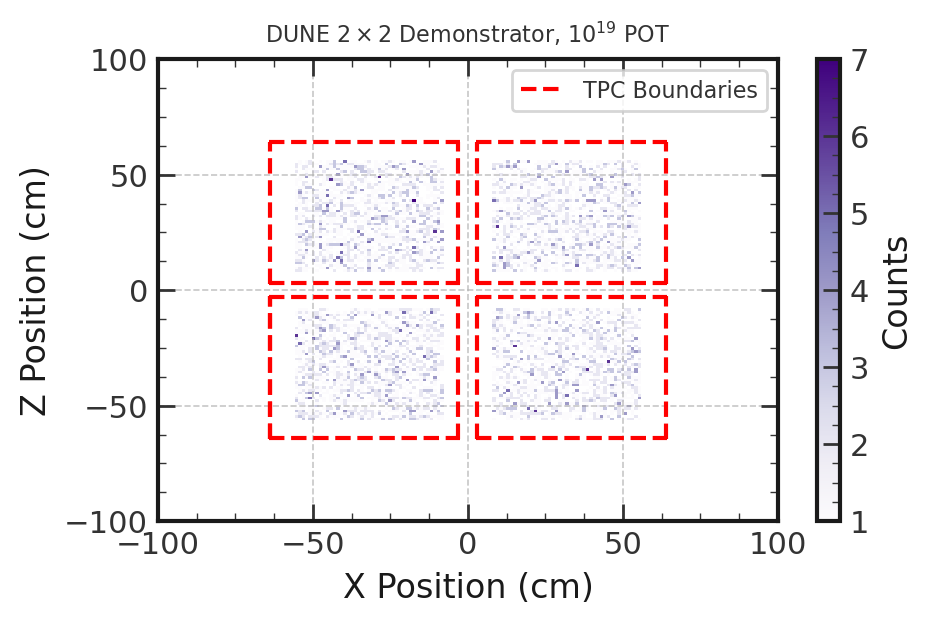

In [311]:
plt.hist2d(vertices_x, vertices_z, bins=100, cmap='Purples', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['x'][1], 'r--')
    plt.plot(traces_anode[i]['x'][1], traces_anode[i]['z'][1], 'r--')
plt.plot(traces_anode[0]['x'][1], traces_anode[0]['z'][1],'r--',label='TPC Boundaries')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '8')
plt.legend(fontsize='8')
plt.xlabel('X Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)

(-100.0, 100.0)

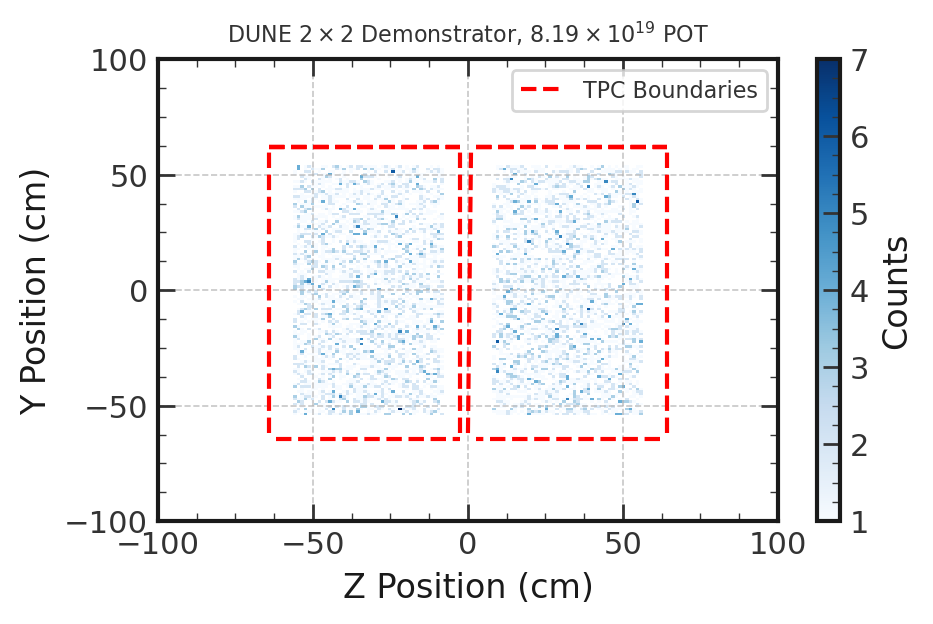

In [158]:
plt.hist2d(vertices_z, vertices_y, bins=100, cmap='Blues', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['y'][1], 'r--')
#     plt.plot(traces_anode[i]['y'][1], traces_anode[i]['z'][1], 'r--')
plt.plot([-traces_anode[0]['y'][1][1], traces_anode[0]['y'][1][1]],'r--',label='TPC Boundaries')
plt.plot([-64.3163,-64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([64.3163,64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([-2.6837,-2.6837 ],[-61.8543,61.8543], 'r--')
plt.plot([-61.8543,-2.6837], [-64.3163,-64.3163 ],'r--')
plt.plot([61.8543,2.6837], [-64.3163,-64.3163 ],'r--')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '8')
plt.legend(fontsize='8')
plt.xlabel('Z Position (cm)')
plt.ylabel('Y Position (cm)')
plt.colorbar(label='Counts')plt.legend()
plt.xlim(-100, 100)
plt.ylim(-100, 100)

# Reconstructed Signal


In [19]:
#cut: signal requiring a vtx that produced a reco sec/prim muon 
def signal_definition(ev_data, pdg, mask):
    signal = mask.copy()  # Create a copy of the mask to avoid modifying the original
    # Iterate over the interactions in fv
    for vtx, bool_value in enumerate(mask):
        n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        muon_found = False
        
        # If the mask is False for this vertex, skip it
        if not bool_value:
            continue
        else:
            # Check if there's any primary muon in the current interaction
            muon_found = np.any(
                (ev_data['rec.common.ixn.dlp.part.dlp.pdg'][n_pre:n_pre + n_particles] == pdg)
            )
        # Update the signal mask based on whether a muon was found
        signal[vtx] = muon_found
          
    return signal

#cut: signal requiring vtx that produced reco prim muon
def signal_definition_prim(ev_data, pdg, mask):
    signal = mask.copy()  # Create a copy of the mask to avoid modifying the original
    # Iterate over the interactions in fv
    for vtx, bool_value in enumerate(mask):
        n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        muon_found = False
        
        # If the mask is False for this vertex, skip it
        if not bool_value:
            continue
        else:
            # Check if there's any primary muon in the current interaction
            muon_found = np.any(
                (ev_data['rec.common.ixn.dlp.part.dlp.primary'][n_pre:n_pre + n_particles] == 1) &
                (ev_data['rec.common.ixn.dlp.part.dlp.pdg'][n_pre:n_pre + n_particles] == pdg)
            )
        # Update the signal mask based on whether a muon was found
        signal[vtx] = muon_found
          
    return signal

#cut: require a reco vtx to produce a reco track 
#cut: require reco vtx to produce track that exit 2x2 downstream
#cut: require a reco vtx to produce a reco track 
#cut: require reco vtx to produce track that exit 2x2 downstream
#cut: require reco vtx to produce track that exit 2x2 downstream
def track_selection_signal(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    x_start_track  = ev_data['rec.nd.lar.dlp.tracks.start.x']
    y_start_track = ev_data['rec.nd.lar.dlp.tracks.start.y']
    z_start_track = ev_data['rec.nd.lar.dlp.tracks.start.z']

    x_end_track = ev_data['rec.nd.lar.dlp.tracks.end.x']
    y_end_track = ev_data['rec.nd.lar.dlp.tracks.end.y']
    z_end_track = ev_data['rec.nd.lar.dlp.tracks.end.z']

    x_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.x']
    y_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.y']
    z_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.z']


    # Stack the coordinates into a single 2D array
    position_vtx = np.vstack((x_coords_vtx, y_coords_vtx, z_coords_vtx)).T
    start_track = np.vstack((x_start_track, y_start_track, z_start_track)).T

    track_on_vtx = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.nd.lar.dlp.tracks..length'][vtx]
        n_pre = np.sum(ev_data['rec.nd.lar.dlp.tracks..length'][:vtx]) if vtx > 0 else 0
        
        vertex_position = position_vtx[vtx]
        # Scan over particles associated with this interaction
        found_match = False
        
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if np.array_equal(vertex_position, start_track[ip]):
                found_match = True
                #if the track is found, then check if the track also goes out the boundary
                if (z_end_track[ip] >= zbound):
                    track_out[vtx] = True 
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    bm, overlap, dx, dy, exit_minerva = Mx2_DS_Match(muon_track,minerva_data)
                    if (exit_minerva == True) and (bm is not None):
                        track_Mx2[vtx] == True
                        # No need to check further if a match is found

        track_on_vtx[vtx] = found_match
    return track_on_vtx,  track_out, track_Mx2


In [120]:
#check if a true proton was neutron-induced 
def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    #iterates over primaries to find parent
    neutron_induced = False
    n_prim =ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t >0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced=True
    return neutron_induced 


#find the best match of a reco particle [ip]
def find_best_match(ev_data, ip):   
    #given the index of a reco particle, finds its best match
    truth_length = ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
    max_overlap = 0
    best_match_idx = 0
    best_match_type = 0
    best_match_pdg=None

    for tp in range(truth_pre, truth_pre + truth_length):
        temp_overlap = ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
        temp_tp_match = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
        temp_tp_type = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][tp]  # 1 prim and 3 second
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_idx = temp_tp_match
            best_match_type = temp_tp_type

    if(best_match_type==3):
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][best_match_idx]
    elif(best_match_type==1):
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][best_match_idx]

    # Find the vertex where the best match index belongs in truth
    vtx_t = None
    for i in range(len(ev_data['rec.mc.nu.sec..length'])):
        p_in_vtx = np.sum(ev_data['rec.mc.nu.sec..length'][:i+1])  # Include the current vertex
        if best_match_idx < p_in_vtx:
            vtx_t = i
            break
        else: continue
    return best_match_idx, best_match_type, best_match_pdg, vtx_t, max_overlap


#Gather the true info of the best match particles  
def get_match_truth_data(ev_data, vtx_t, best_match_idx):
    #store truth data
    match_truth_data = {
        'track_length_truth': None,
        'vtx_distance_truth': None,
        'E_neutrino': None,
        'is_in_FV': None,
        'E_bestmatch_proton': None
    }

    # Calculate track properties
    track_length_truth, vtx_distance_truth = calculate_track_properties(
        (ev_data['rec.mc.nu.sec.start_pos.x'][best_match_idx], 
         ev_data['rec.mc.nu.sec.start_pos.y'][best_match_idx],
         ev_data['rec.mc.nu.sec.start_pos.z'][best_match_idx]
        ),
        (ev_data['rec.mc.nu.sec.end_pos.x'][best_match_idx], 
         ev_data['rec.mc.nu.sec.end_pos.y'][best_match_idx],
         ev_data['rec.mc.nu.sec.end_pos.z'][best_match_idx]
        ),
        (ev_data['rec.mc.nu.vtx.x'][vtx_t],
         ev_data['rec.mc.nu.vtx.y'][vtx_t],
         ev_data['rec.mc.nu.vtx.z'][vtx_t]
        )
    )
    #Update the dictionary with calculated values, vertex index, E int
    match_truth_data['E_neutrino'] = ev_data['rec.mc.nu.E'][vtx_t]
    match_truth_data['is_in_FV'] = isContainedFV(ev_data['rec.mc.nu.vtx.x'][vtx_t], ev_data['rec.mc.nu.vtx.y'][vtx_t], ev_data['rec.mc.nu.vtx.z'][vtx_t])
    match_truth_data['track_length_truth'] = track_length_truth
    match_truth_data['vtx_distance_truth'] = vtx_distance_truth
    match_truth_data['E_bestmatch_proton'] = ev_data['rec.mc.nu.sec.p.E'][best_match_idx]
    return match_truth_data





#Gather reco info of the candidates that passed all filters/cuts
def get_match_reco_data(ev_data, vtx_r, ip):
    #store data dict
    match_reco_data = {
        'track_length_reco': None,
        'vtx_distance_reco': None,
        'E_neutrino': None,
        'E_proton': None
    }
    #calculate track info
    track_length_reco, vtx_distance_reco = calculate_track_properties(
        (ev_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ),
        (ev_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ),
        (ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r],
         ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r],
         ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r]
        )
    )
    #Update the dictionary with calculated values, vertex index, reco E
    match_reco_data['E_proton'] = ev_data['rec.common.ixn.dlp.part.dlp.E'][ip]
    match_reco_data['track_length_reco'] = track_length_reco
    match_reco_data['vtx_distance_reco'] = vtx_distance_reco
    
    return match_reco_data

def Mx2_DS_Match(reco_track, minerva_data):


    # Variables to return 
    ds_dp = 0 
    bm_index = None
    exit_minerva = False
    deltaX = None
    deltaY = None


    tpc_track_s = reco_track[0]
    tpc_track_e = reco_track[1]

    # Data of tpc track 
    tpc_dx = tpc_track_e[0] - tpc_track_s[0]  
    tpc_dy = tpc_track_e[1] - tpc_track_s[1]
    tpc_dz = tpc_track_e[2] - tpc_track_s[2]
    tpc_trk_length = np.sqrt(np.square(tpc_dx) + np.square(tpc_dy) + np.square(tpc_dz))
    tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length
    # print(f"2x2 track length {tpc_trk_length:.2f} cm")

    if(tpc_dir_vec[2]<0):
        # print("Flipping track direction")
        # print(f"Original start {tpc_track_s}")
        # print(f"Original end {tpc_track_e}")
        tpc_dir_vec[2] = -1*tpc_dir_vec[2]
        temp = tpc_track_s
        tpc_track_s = tpc_track_e
        tpc_track_e = temp 
        # print(f"New start {tpc_track_s}")
        # print(f"New end {tpc_track_e}")

    # Hard coded 5 cm (?)
    if(tpc_trk_length>5):
        if(tpc_track_s[2] > 58 or tpc_track_e[2] > 58):
            temp_punchthrough = -1
            nminerva_tracks = np.sum(minerva_data['rec.nd.minerva.ixn.tracks..length'])
            for itrack in range(nminerva_tracks):

                mn_track_sx = minerva_data['rec.nd.minerva.ixn.tracks.start.x'][itrack]
                mn_track_sy = minerva_data['rec.nd.minerva.ixn.tracks.start.y'][itrack]
                mn_track_sz = minerva_data['rec.nd.minerva.ixn.tracks.start.z'][itrack]

                mn_track_ex = minerva_data['rec.nd.minerva.ixn.tracks.end.x'][itrack]
                mn_track_ey = minerva_data['rec.nd.minerva.ixn.tracks.end.y'][itrack]
                mn_track_ez = minerva_data['rec.nd.minerva.ixn.tracks.end.z'][itrack]

                if(mn_track_ez>300):
                    exit_minerva=True


                # Only DS track
                if(mn_track_sz > 0 and mn_track_ez > 0 and
                   ((tpc_track_s[2] > 58) or (tpc_track_e[2] > 58))):
                    mn_dx = mn_track_ex - mn_track_sx
                    mn_dy = mn_track_ey - mn_track_sy
                    mn_dz = mn_track_ez - mn_track_sz
                    mn_length = np.sqrt(np.square(mn_dx) + 
                                        np.square(mn_dy) + 
                                        np.square(mn_dz))    

                    if(mn_length<10):
                        continue 
                    mn_dir = np.array([
                        mn_dx,
                        mn_dy,
                        mn_dz
                    ])/mn_length
                    dot_product = np.dot(tpc_dir_vec,mn_dir)  
                    extrapdz = mn_track_sz - tpc_track_e[2]
                    extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
                    extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
                    diffextrap = np.sqrt(np.square(extrapdy - mn_track_sy))

                    if(ds_dp < dot_product and np.abs(extrapdy)< 10):
                        ds_dp = dot_product
                        bm_index = itrack
                        deltaX = extrapdx 
                        deltaY = extrapdy

    return bm_index,ds_dp,deltaX,deltaY,exit_minerva

In [88]:
#store num reco vtx for the cuts
num_neutrinos_dv_r=0 # in dv
num_neutrinos_fv_r=0 # in fv
num_neutrinos_muons = 0 #produced reco muon
num_neutrinos_muon_fv = 0 #produced reco muon in fv
num_neutrinos_prim_mu_fv=0 #produced prim muon in fv
#for tracks
num_track_fv = 0 # produced a track in fv
num_track_vtx_fv =0 #produced track that stat on vtx
num_track_vtx_out_fv=0 #produced track start on vtx and exit 2x2 downstream
num_track_Mx2_fv = 0 #num of tracks that crossed minerva 


reco_sec_proton=0
reco_primproton_with_bm_sec_proton  =0
reco_prim_proton =0
candidate_not_in_signal=0
candidate_in_signal =0 
count_sec =0

#store track length and distance to vtx 
track_lenghts_match_truth = [] #true particles best match 
vtx_distances_match_truth =[]  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#positions of the vtx that passed the reco signal cuts
vtx_x_signal=[]
vtx_y_signal=[]
vtx_z_signal=[]
#positions of the vtx the reco candidates
vtx_x_candidates=[]
vtx_y_candidates=[]
vtx_z_candidates=[]

candidate_event_vtx_r = []
candidate_event_vtx_t = []

vtx_x_bmcandidates=[]
vtx_y_bmcandidates=[]
vtx_z_bmcandidates=[]


bmnot_a_proton =[]
bmtrue_prim_proton=[]
bmtrue_intermediate_proton=[]

#stores values of what was reconstructed as sec proton but was something else
bmnot_a_proton_dic = {
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'vtx_t': [],
    'vtx_r': [],
    'max_overlap': [],
    'ev': [],
    'reco_inx': []
}

for ev in range(len(df)):
   # print(ev)
    
    ev_data = df.iloc[ev]
    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    
    
     
    #------------------------ true masks -----------
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )



   #---------Reco masks---------------

    mask_dv_r = (
        (ev_data['rec.common.ixn.dlp.vtx.x'] >= anode_xs[0]) & (ev_data['rec.common.ixn.dlp.vtx.x'] <= anode_xs[3]) &
        (ev_data['rec.common.ixn.dlp.vtx.y'] >= anode_ys[0]) & (ev_data['rec.common.ixn.dlp.vtx.y'] <= anode_ys[1]) &
        (ev_data['rec.common.ixn.dlp.vtx.z'] >= anode_zs[0]) & (ev_data['rec.common.ixn.dlp.vtx.z'] <= anode_zs[3]) 
    )
    
    #mask vertex on the fiducial volume
    mask_fv_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])<zbound-tpc_dist)
    )
    
    num_neutrinos_dv_r += np.sum(mask_dv_r)
    num_neutrinos_fv_r += np.sum(mask_fv_r)
    #signals muons + fv
    signal_fv_muons = signal_definition(ev_data,  pdg_tab.muon, mask_fv_r)  
    num_neutrinos_muon_fv += np.sum(signal_fv_muons) 
    #signal prim muon in fv 
    signal_prim_muon_fv = signal_definition_prim(ev_data,  pdg_tab.muon, mask_fv_r)
    num_neutrinos_prim_mu_fv += np.sum(signal_prim_muon_fv) 
    #signal tracks in fv
    signal_tracks_fv= (ev_data['rec.nd.lar.dlp.tracks..length'] != 0) & (mask_fv_r)
    num_track_fv += np.sum(signal_tracks_fv)
    #get the tracks on vertex
    tracks_vtx, track_vtx_out, tracks_mx2 = track_selection_signal(ev_data,ev)
    tracks_vtx_fv = (tracks_vtx) & (mask_fv_r) #get them now in fv
    tracks_vtx_out_fv = (track_vtx_out) & (mask_fv_r)
    track_Mx2_fv= (track_vtx_out)&(mask_fv_r)
    #track_Mx2_fv = (track_Mx2) & (mask_fv_r)
    num_track_vtx_fv += np.sum(tracks_vtx_fv)
    num_track_vtx_out_fv += np.sum(tracks_vtx_out_fv)
    num_track_Mx2_fv += np.sum(track_Mx2_fv)

    # test_muon_track = [[reco_sx,reco_sy,reco_sz],[reco_ex,reco_ey,reco_ez]]
    # bm, overlap, dx, dy, exit_minerva = Mx2_DS_Match(test_muon_track,minerva_data)

    for vtx_r, value in enumerate(tracks_vtx_out_fv):
        if value == True:
            n_reco_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx_r]
            n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx_r]) if vtx_r>0 else 0
            
            #store info of the vertices that passsed the cuts
            vtx_x_signal.append(ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r])
            vtx_y_signal.append(ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r])
            vtx_z_signal.append(ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r])
            
            # Scan over particles associated with this ixn 
            for ip in range(n_pre, n_pre + n_reco_particles):
                if (
                    ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] == 0 and
                    ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip] == pdg_tab.proton 
                ): 
                    reco_sec_proton+=1
                    #if the particle was reco sec proton, find best match
                    best_match_idx, best_match_type, best_match_pdg, vtx_t, max_overlap = find_best_match(ev_data,ip)
                    if (best_match_pdg == pdg_tab.proton and best_match_type == 3):
                        count_sec+=1
                        #if best match is also sec proton, check if parent is neutron
                        proton_parent_id = ev_data['rec.mc.nu.sec.parent'][best_match_idx]
                        neutron_induced=was_neutron_induced(ev_data,vtx_t, proton_parent_id)
    
                        if neutron_induced == True: 
                            candidate_not_in_signal +=1
                          
                            if ev_data['rec.mc.nu.E'][vtx_t] in ev_data['rec.mc.nu.E'][mask_signal]:
                                match_truth_data = get_match_truth_data(ev_data, vtx_t, best_match_idx)
                                track_lenghts_match_truth.append(match_truth_data['track_length_truth'])
                                vtx_distances_match_truth.append(match_truth_data['vtx_distance_truth'])
                                #reco tracks
                                match_reco_data = get_match_reco_data(ev_data, vtx_r,ip)
                                track_lenghts_reco.append(match_reco_data['track_length_reco'])
                                vtx_distances_reco.append(match_reco_data['vtx_distance_reco'])
                                #store position of the vertices of the candidaes
                                vtx_x_candidates.append(ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r])
                                vtx_y_candidates.append(ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r])
                                vtx_z_candidates.append(ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r])
                                vtx_x_bmcandidates.append(ev_data['rec.mc.nu.vtx.x'][vtx_t])
                                vtx_y_bmcandidates.append(ev_data['rec.mc.nu.vtx.x'][vtx_t])
                                vtx_z_bmcandidates.append(ev_data['rec.mc.nu.vtx.x'][vtx_t])
                                candidate_event_vtx_r.append(np.array([ev, vtx_r]))
                                candidate_event_vtx_t.append(np.array([ev, vtx_t]))
                                E_bm_proton.append(match_truth_data['E_bestmatch_proton'])
                                E_reco_proton.append(match_reco_data['E_proton'])

                    # elif (best_match_pdg == pdg_tab.proton and best_match_type == 1):
                    #     bmtrue_prim_proton.append(ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
                    # elif (best_match_pdg == pdg_tab.proton and best_match_type == 2):
                    #     bmtrue_intermediate_proton.append(ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
                    elif (best_match_idx !=None) and (best_match_pdg !=None) and (best_match_type !=None) and (vtx_t!= None) : 
#                        bmnot_a_proton.append(ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
                        bmnot_a_proton_dic['best_match_idx'].append(best_match_idx)
                        bmnot_a_proton_dic['best_match_pdg'].append(best_match_pdg)
                        bmnot_a_proton_dic['vtx_t'].append(vtx_t)
                        bmnot_a_proton_dic['vtx_r'].append(vtx_r)
                        bmnot_a_proton_dic['max_overlap'].append(max_overlap)
                        bmnot_a_proton_dic['ev'].append(ev)
                        bmnot_a_proton_dic['reco_inx'].append(ip)



                #look for particles that were tagged as prim proton but had sec proton best match
                if (
                    ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] == 1 and
                    ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip] == pdg_tab.proton 
                ): 
                    #reco_prim_proton+=1
                    #if the particle was reco prim proton, find best match
                    best_match_idx, best_match_type, best_match_pdg, vtx_t, max_overlap = find_best_match(ev_data,ip)
                    if (best_match_pdg == pdg_tab.proton and best_match_type == 3):
                        #if best match is also sec proton, check if parent is neutron
                        proton_parent_id = ev_data['rec.mc.nu.sec.parent'][best_match_idx]
                        neutron_induced=was_neutron_induced(ev_data,vtx_t, proton_parent_id)
                      
                        if neutron_induced == True: 
                            reco_primproton_with_bm_sec_proton +=1
                            #truth tracks
                            
                          
                            if ev_data['rec.mc.nu.E'][vtx_t] in ev_data['rec.mc.nu.E'][mask_signal]:

                                candidate_in_signal +=1
                        
                                match_truth_data = get_match_truth_data(ev_data, vtx_t, best_match_idx)
                                track_lenghts_match_truth.append(match_truth_data['track_length_truth'])
                                vtx_distances_match_truth.append(match_truth_data['vtx_distance_truth'])
                                #reco tracks
                                match_reco_data = get_match_reco_data(ev_data, vtx_r,ip)
                                track_lenghts_reco.append(match_reco_data['track_length_reco'])
                                vtx_distances_reco.append(match_reco_data['vtx_distance_reco'])
                                #store position of the vertices of the candidaes
                                vtx_x_candidates.append(ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r])
                                vtx_y_candidates.append(ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r])
                                vtx_z_candidates.append(ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r])
                                candidate_event_vtx_r.append(np.array([ev, vtx_r]))
                                candidate_event_vtx_t.append(np.array([ev, vtx_t]))
                                E_bm_proton.append(match_truth_data['E_bestmatch_proton'])
                                E_reco_proton.append(match_reco_data['E_proton'])
print(len(track_lenghts_reco), len(track_lenghts_match_truth))


/tmp/ipykernel_1408751/1074249815.py:191: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/tmp/ipykernel_1408751/1074249815.py:192: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/tmp/ipykernel_1408751/1074249815.py:139: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


115 115


In [89]:
num_track_Mx2_fv, num_track_vtx_out_fv

(1642, 1642)

In [86]:
np.min(bmnot_a_proton_dic['max_overlap'])

# Convert the list to a NumPy array
max_overlap_array = np.array(bmnot_a_proton_dic['max_overlap'])
pdg_array = np.array(bmnot_a_proton_dic['best_match_pdg'])

# Create a boolean array where True indicates the value is 0
boolean_array = pdg_array == pdg_tab.neutron

# Print the boolean array
print(boolean_array)
np.sum(boolean_array)

#len(pdg_array),len(boolean_array)
max_overlap_array[boolean_array]

[False False False ...  True  True False]


array([0.9811321 , 0.85365856, 0.9074074 , 0.9019608 , 1.        ,
       0.92105263, 0.03030303, 0.28282827, 0.98734176, 0.47619048,
       0.71428573, 0.57894737, 0.08426967, 0.62222224, 0.6146789 ,
       0.8       , 0.3773585 , 0.91964287, 0.9935065 , 0.81578946,
       0.88235295, 0.9863946 , 0.3956044 , 0.8021978 , 0.8679245 ,
       1.        , 0.63325185, 1.        , 0.9285714 , 0.31325302,
       0.07228915, 0.9120879 , 0.5714286 , 0.7407407 , 0.5769231 ,
       0.25      , 0.25      , 0.875     , 0.835     , 0.75      ,
       0.45882353, 0.61904764, 0.8076923 , 0.9189189 , 0.24      ,
       1.        , 0.70958906, 0.98275864, 0.8372093 , 0.96      ,
       0.7826087 , 0.5       , 0.42975205, 0.34513274, 0.9166667 ,
       0.9399478 , 1.        , 0.12650603, 0.9777778 , 0.6451613 ,
       0.9       , 0.4473684 , 0.7411765 , 0.9836066 , 1.        ,
       0.8333333 , 0.9       , 0.1147541 , 0.9916667 , 0.25652173,
       0.80128205, 0.5952381 , 0.16      , 0.38709676, 0.51111

In [322]:
print(f'1.Spine identified as sec protons {(reco_sec_proton)} particles')
print(f'2.Spine identified as sec protons {len(track_lenghts_reco)} particles that had true best match neutron-induced proton (not neccesarly from CCnumuArFV)')
print(f'3.Spine identified as sec protons {len(track_lenghts_reco)} particles that had true best match neutron-induced proton in CC munu Ar FV')
print('where is making mistakes?')
#print(f'5.Spine identified as sec protons {len(bmtrue_prim_proton)} particles that had true best match prim proton')
print(f'6.Spine identified as sec protons {len(bmnot_a_proton)} particles that didnt have proton best match')
print(f'6.Spine identified as sec protons {(count_sec)} particles that did have proton best match')
print('what did he miss?')
print(f'7.Spine identified as prim protons {reco_primproton_with_bm_sec_proton} particles that had true best match neutron-induced proton not from  neccesarly CCmunuArFV')
print(f'4.Spine identified as prim protons {candidate_in_signal} particles that had true best match neutron-induced proton from CCmunuArFV')
      


1.Spine identified as sec protons 2667 particles
2.Spine identified as sec protons 113 particles that had true best match neutron-induced proton (not neccesarly from CCnumuArFV)
3.Spine identified as sec protons 113 particles that had true best match neutron-induced proton in CC munu Ar FV
where is making mistakes?
6.Spine identified as sec protons 1493 particles that didnt have proton best match
6.Spine identified as sec protons 1174 particles that did have proton best match
what did he miss?
7.Spine identified as prim protons 27 particles that had true best match neutron-induced proton not from  neccesarly CCmunuArFV
4.Spine identified as prim protons 13 particles that had true best match neutron-induced proton from CCmunuArFV


In [320]:
len(bmnot_a_proton), 1419

1493

In [96]:
bmnot_a_proton_dic['best_match_pdg']


# Convert to NumPy array if it's not already
data_pdg = np.array(bmnot_a_proton_dic['best_match_pdg'])
data_vtx_t= np.array(bmnot_a_proton_dic['vtx_t'])
data_vtx_r= np.array(bmnot_a_proton_dic['vtx_r'])
data_ev= np.array(bmnot_a_proton_dic['ev'])
data_recoinx= np.array(bmnot_a_proton_dic['reco_inx'])

# Remove None values if present
data_pdg = data_pdg[data_pdg != None]
data_vtx_t = data_vtx_t[data_vtx_t != None]

len(data_pdg), len(data_vtx_t),  len(data_vtx_r), len(data_ev), len(data_recoinx)
neutrons_ev = data_ev[data_pdg==pdg_tab.neutron]
neutrons_recoinx = data_recoinx[data_pdg==pdg_tab.neutron]
neutrons_vtxt = data_vtx_t[data_pdg==pdg_tab.neutron]
neutrons_vtxr = data_vtx_r[data_pdg==pdg_tab.neutron]

In [146]:
neutrons_ev, neutrons_recoinx, neutrons_vtxr, neutrons_vtxt

(array([  1986,   2742,   2742,   4519,   4519,   5261,   5540,   5540,
          9209,  13487,  14757,  15857,  19160,  19160,  22650,  23220,
         23220,  23871,  26354,  26525,  29330,  31043,  33816,  37900,
         42528,  42528,  44206,  44376,  49435,  50388,  50388,  51446,
         52056,  52495,  52495,  57025,  57025,  65515,  69639,  70364,
         72540,  72540,  81173,  86050,  86698,  88762,  90889,  90948,
         90948,  95393,  95393,  95393,  96440, 106785, 107863, 109077,
        110431, 110915, 110915, 112552, 116748, 116748, 118941, 125166,
        129652, 129652, 130893, 130893, 133709, 135944, 146584, 149379,
        149379, 149867, 150421, 150421, 152569, 152569, 153084, 153084,
        154001, 156824, 156836, 157920, 157920, 158164, 158164, 160728,
        163423, 165420, 165420, 165502, 165502, 165903, 167976, 171558,
        172227, 173355, 173355, 173795]),
 array([ 10,   7,  13,  14,  15,  26,  11,  12,   9,   8,   4,   8,  13,
         15,   8,   7

In [144]:
idx= 10
n_vtxr = 2
n_vtxt = 4
ev= 1986

def reco_backtrack(df_test,ixn_index):
    n_ixn = len(df_test['rec.common.ixn.dlp.id'])
    n_particles = df_test['rec.common.ixn.dlp.part.dlp..length'][ixn_index]
    if(ixn_index==0):
        n_pre = 0
    else: 
        n_pre = np.sum(df_test['rec.common.ixn.dlp.part.dlp..length'][:ixn_index]) 
    print('Number of interactions in this event ',n_ixn)
    print('Printing info for interaction ', ixn_index)
    print(f'This interaction has {n_particles} reco particles')

    # Scan over particles associated to this ixn 
    for ip in range(n_pre,n_pre + n_particles):
        #print(ip)
        # Check if particle is primary 
        is_primary = df_test['rec.common.ixn.dlp.part.dlp.primary'][ip]
        if(is_primary==False):
            continue 
        else:
            # Get reco PDG
            reco_pdg = df_test['rec.common.ixn.dlp.part.dlp.pdg'][ip]
            print(f"Particle {ip} is a {reco_pdg} primary")
            if(reco_pdg==2212):
                truth_length = df_test['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
                truth_pre = np.sum(df_test['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
                print(f'With {truth_length} overlapping particles')
                max_overlap = 0
                best_match_idx = 0
                best_match_type = 0
                # Need to do the same trick as for scan over reco particles
                for tp in range(truth_pre,truth_pre+truth_length):
                    temp_overlap = df_test['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
                    temp_tp_match = df_test['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
                    temp_tp_type = df_test['rec.common.ixn.dlp.part.dlp.truth.type'][tp] # 1 prim and 3 second
                    print(f'True ({temp_tp_type}) particle {temp_tp_match} has this amount of overlap {temp_overlap}')
                    if(temp_overlap>max_overlap):
                        max_overlap=temp_overlap
                        best_match_idx=temp_tp_match
                        best_match_type=temp_tp_type


                if(best_match_type==3):
                    best_match_pdg = df_test['rec.mc.nu.sec.pdg'][best_match_idx]
                    print('true secondary, PDG of best match: ', best_match_pdg)
                elif(best_match_type==1):
                    best_match_pdg = df_test['rec.mc.nu.prim.pdg'][best_match_idx]
                    print('true primary, PDG of best match: ', best_match_pdg)

                if best_match_idx != None:
                    for i in range(len(ev_data['rec.mc.nu.sec..length'])):
                        p_in_vtx = np.sum(ev_data['rec.mc.nu.sec..length'][:i+1])  # Include the current vertex
                        if best_match_idx < p_in_vtx:
                            vtx_t = i
                            print(vtx_t)
                            break
                    else: continue

#find the best match of a reco particle [ip]
def find_best_match(df_test, vtx_r):
    best_match_pdg= None
    best_match_idx=None
    best_match_type=None
    max_overlap=None
    vtx_t = None
    n_ixn = len(df_test['rec.common.ixn.dlp.id'])
    n_particles = df_test['rec.common.ixn.dlp.part.dlp..length'][vtx_r]
    if(vtx_r==0):
        n_pre = 0
    else: 
        n_pre = np.sum(df_test['rec.common.ixn.dlp.part.dlp..length'][:vtx_r]) 
    for ip in range(n_pre,n_pre + n_particles):
        #print(ip)
        # Check if particle is primary 
        is_primary = df_test['rec.common.ixn.dlp.part.dlp.primary'][ip]
        if(is_primary==False):
            continue    
        else:
            # Get reco PDG
            reco_pdg = df_test['rec.common.ixn.dlp.part.dlp.pdg'][ip]
            print(f"Particle {ip} is a {reco_pdg} primary")
            if(reco_pdg==2212):
                truth_length = df_test['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
                truth_pre = np.sum(df_test['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
                print(f'With {truth_length} overlapping particles')
                max_overlap = 0
                best_match_idx = 0
                best_match_type = 0
                # Need to do the same trick as for scan over reco particles
                for tp in range(truth_pre,truth_pre+truth_length):
                    temp_overlap = df_test['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
                    temp_tp_match = df_test['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
                    temp_tp_type = df_test['rec.common.ixn.dlp.part.dlp.truth.type'][tp] # 1 prim and 3 second
                    print(f'True ({temp_tp_type}) particle {temp_tp_match} has this amount of overlap {temp_overlap}')
                    if(temp_overlap>max_overlap):
                        max_overlap=temp_overlap
                        best_match_idx=temp_tp_match
                        best_match_type=temp_tp_type

                if(best_match_type==3):
                    best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][best_match_idx]
                elif(best_match_type==1):
                    best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][best_match_idx]

        # Find the vertex where the best match index belongs in truth
        if best_match_idx != None:
            for i in range(len(ev_data['rec.mc.nu.sec..length'])):
                p_in_vtx = np.sum(ev_data['rec.mc.nu.sec..length'][:i+1])  # Include the current vertex
                if best_match_idx < p_in_vtx:
                    vtx_t = i
                    break
            else: continue
    return best_match_idx, best_match_type, best_match_pdg, max_overlap, vtx_t

In [145]:
idx= 10
n_vtxr = 2
n_vtxt = 4
ev= 1986
ev_check = df.iloc[ev]
print(f'event {ev}')
print(f'Particles per vertex {ev_check['rec.common.ixn.dlp.part.dlp..length']}')
print(f'reco particle {idx} is a {ev_check['rec.common.ixn.dlp.part.dlp.pdg'][idx]}')
ev_check['rec.common.ixn.dlp.part.dlp..length'][n_vtxr]
reco_backtrack(ev_check, n_vtxr)
#nbest_match_idx, nbest_match_type, nbest_match_pdg, nmax_overlap, vtx_t = find_best_match(ev_check, n_vtxr)
#print(nbest_match_idx, nbest_match_type, nbest_match_pdg, nmax_overlap)

event 1986
Particles per vertex [2 4 6 1]
reco particle 10 is a 2212
Number of interactions in this event  4
Printing info for interaction  2
This interaction has 6 reco particles
Particle 11 is a 13 primary


In [249]:
# Define the dictionary with PDG codes and corresponding particles
pdg_dictionary = {
    -321: "Negative Kaon (K⁻)",
    -311: "Negative Kaon (K⁻)",
    -211: "Negative Pion (π⁻)",
    -14: "Anti-Muon Neutrino (ν̅_μ)",
    -13: "Anti-Muon (μ⁺)",
    -12: "Muon Neutrino (ν_μ)",
    -11: "Positron (e⁺)",
    11: "Electron (e⁻)",
    13: "Muon (μ⁻)",
    14: "Muon Neutrino (ν_μ)",
    22: "Photon (γ)",
    111: "Neutral Pion (π⁰)",
    130: "Neutral Kaon (K⁰)",
    211: "Positive Pion (π⁺)",
    310: "Neutral Kaon (K⁰)",
    311: "Neutral Kaon (K⁰)",
    321: "Positive Kaon (K⁺)",
    2112: "Neutron (n)",
    3222: "Sigma Plus Baryon (Σ⁺)"
}

# Print the dictionary to check the contents
print(pdg_dictionary)
1419

{-321: 'Negative Kaon (K⁻)', -311: 'Negative Kaon (K⁻)', -211: 'Negative Pion (π⁻)', -14: 'Anti-Muon Neutrino (ν̅_μ)', -13: 'Anti-Muon (μ⁺)', -12: 'Muon Neutrino (ν_μ)', -11: 'Positron (e⁺)', 11: 'Electron (e⁻)', 13: 'Muon (μ⁻)', 14: 'Muon Neutrino (ν_μ)', 22: 'Photon (γ)', 111: 'Neutral Pion (π⁰)', 130: 'Neutral Kaon (K⁰)', 211: 'Positive Pion (π⁺)', 310: 'Neutral Kaon (K⁰)', 311: 'Neutral Kaon (K⁰)', 321: 'Positive Kaon (K⁺)', 2112: 'Neutron (n)', 3222: 'Sigma Plus Baryon (Σ⁺)'}


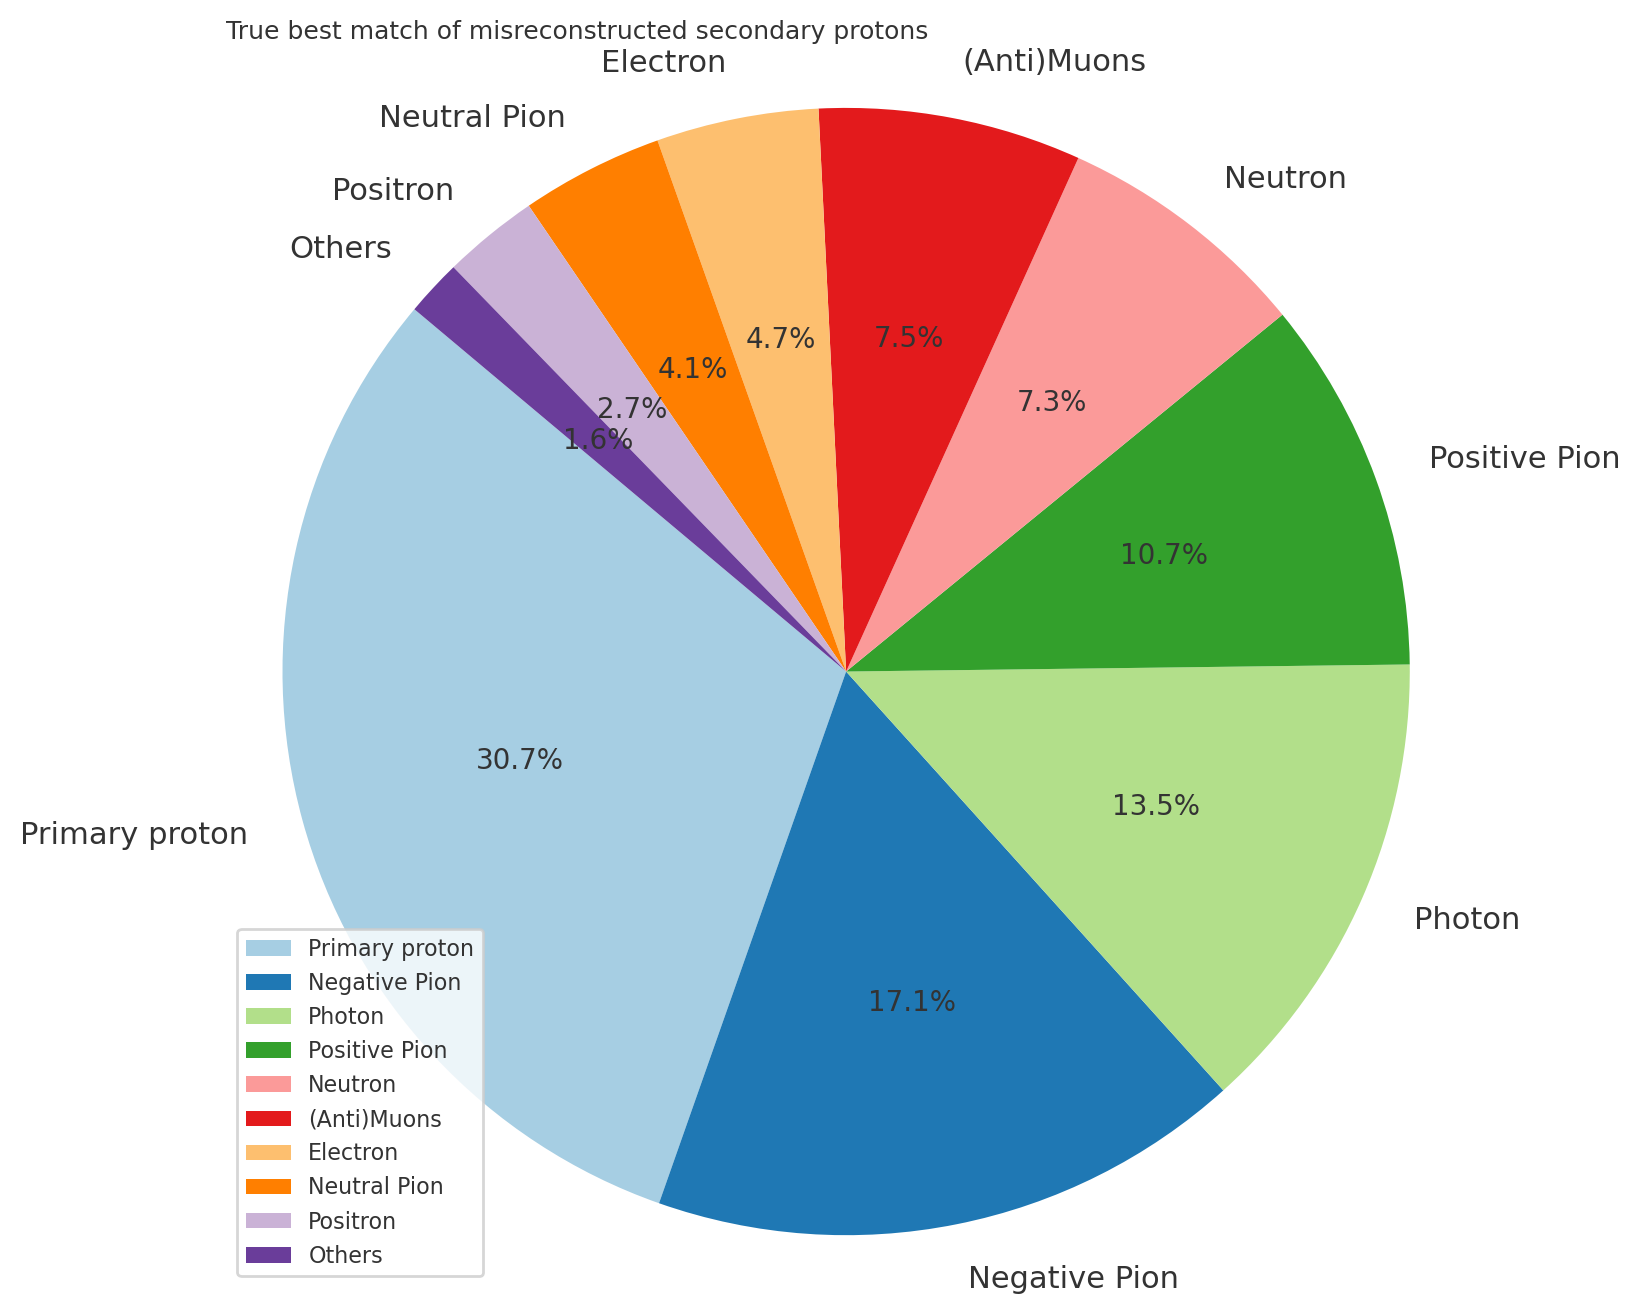

In [25]:
dic = {
    'Primary proton': 436,
    'Negative Pion': 242,
    'Photon': 192,
    'Positive Pion': 152,
    'Neutron': 104,
    '(Anti)Muons': 107,
    'Electron': 66,
    'Neutral Pion': 58,
    'Positron': 39,
    'Others' : 23
}

labels = dic.keys()
sizes = dic.values()
colors = plt.cm.Paired(range(len(labels)))  # Color map for distinct colors

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)#, fontsize=8)
plt.title('True best match of misreconstructed secondary protons', fontsize=9,loc='left')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(fontsize =8,loc='lower left')
plt.show()

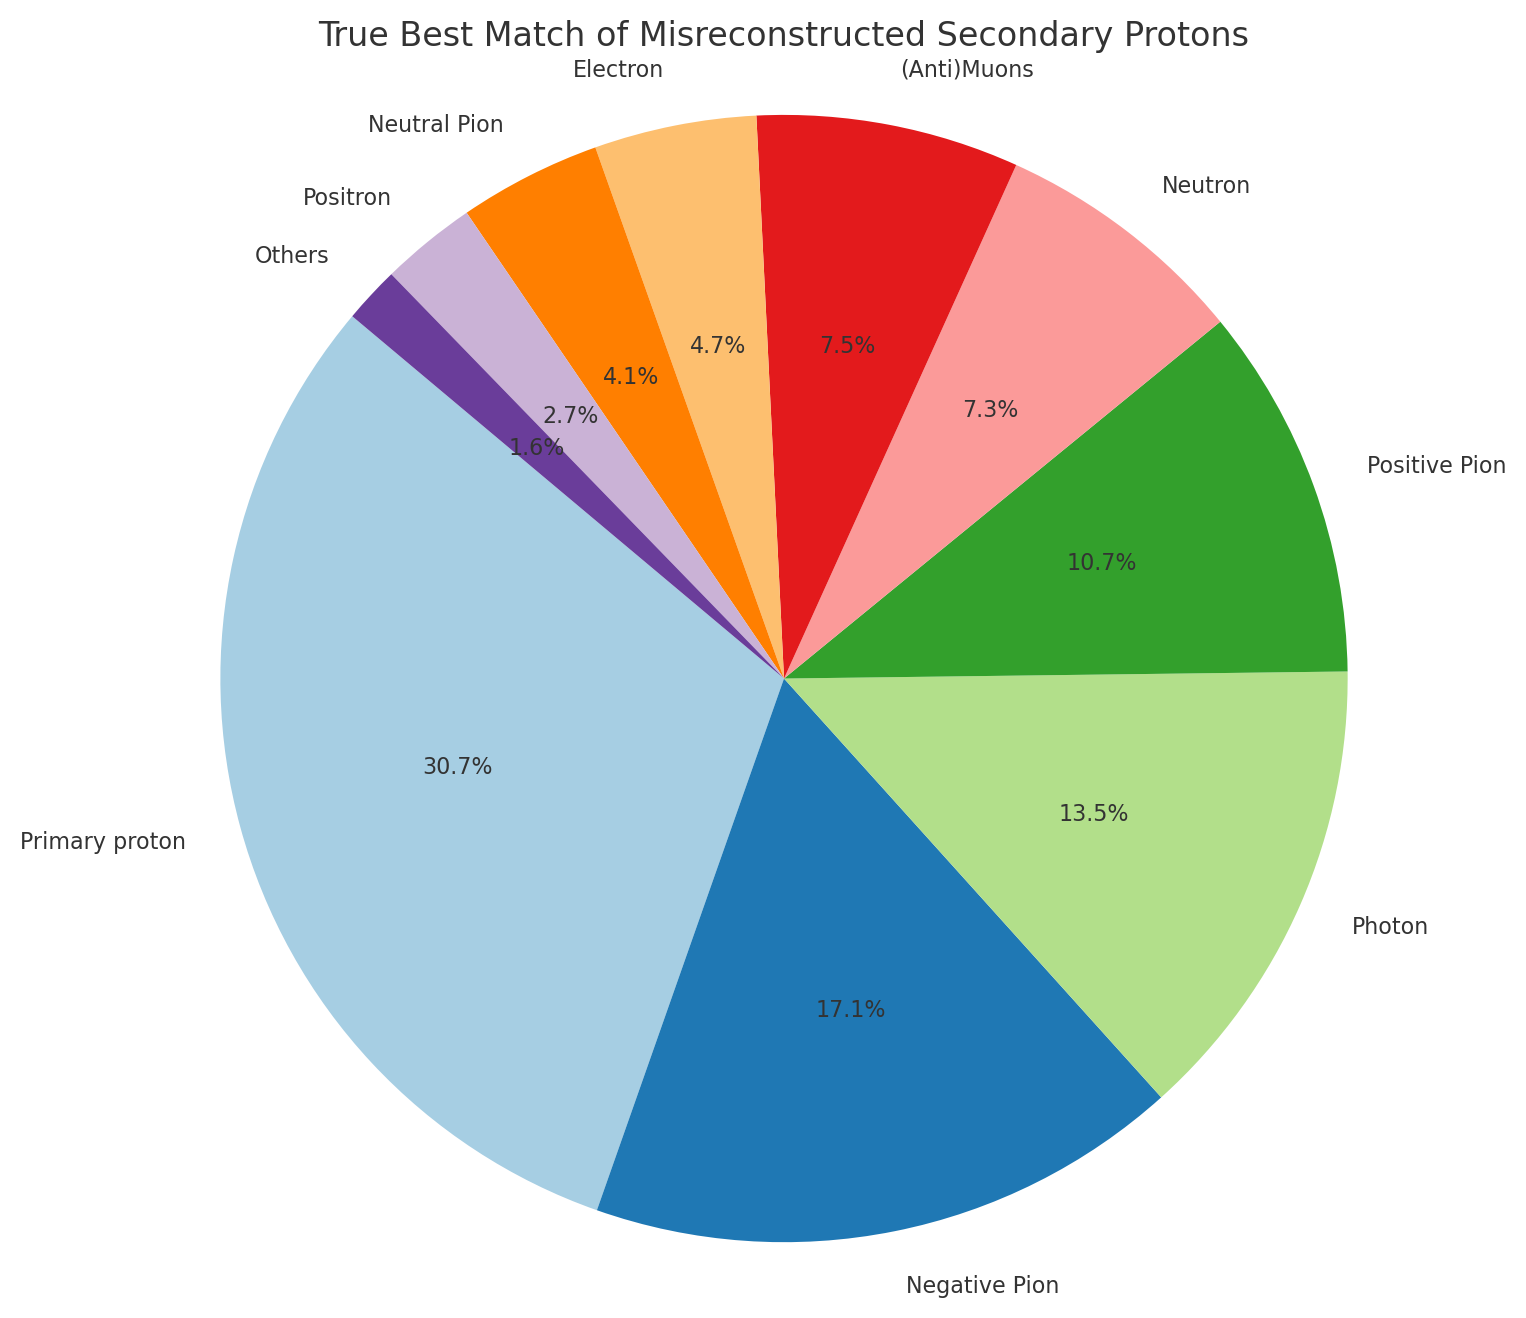

In [283]:
import matplotlib.pyplot as plt

# Define the dictionary with particle names and counts
dic = {
    'Primary proton': 436,
    'Negative Pion': 242,
    'Photon': 192,
    'Positive Pion': 152,
    'Neutron': 104,
    '(Anti)Muons': 107,
    'Electron': 66,
    'Neutral Pion': 58,
    'Positron': 39,
    'Others': 23
}

labels = dic.keys()
sizes = dic.values()
colors = plt.cm.Paired(range(len(labels)))  # Color map for distinct colors

# Plotting the pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 8}  # Set the font size of the labels
)

# Customize the legend
plt.title('True Best Match of Misreconstructed Secondary Protons')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
#plt.legend(fontsize=8, loc='lower left')

plt.show()


In [255]:
# import matplotlib.pyplot as plt
# from collections import Counter


# # Count occurrences
# count = Counter(data_array)

# # Data for pie chart
# labels = count.keys()
# sizes = count.values()
# colors = plt.cm.Paired(range(len(labels)))  # Color map for distinct colors

# # Plotting the pie chart
# plt.figure(figsize=(8, 8))
# plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
# plt.title('Pie Chart of Value Counts')
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
# plt.legend()
# plt.show()
# 22,11,211, 2112,11,13,321,13,14

# 311, 321,310,3222,130,12

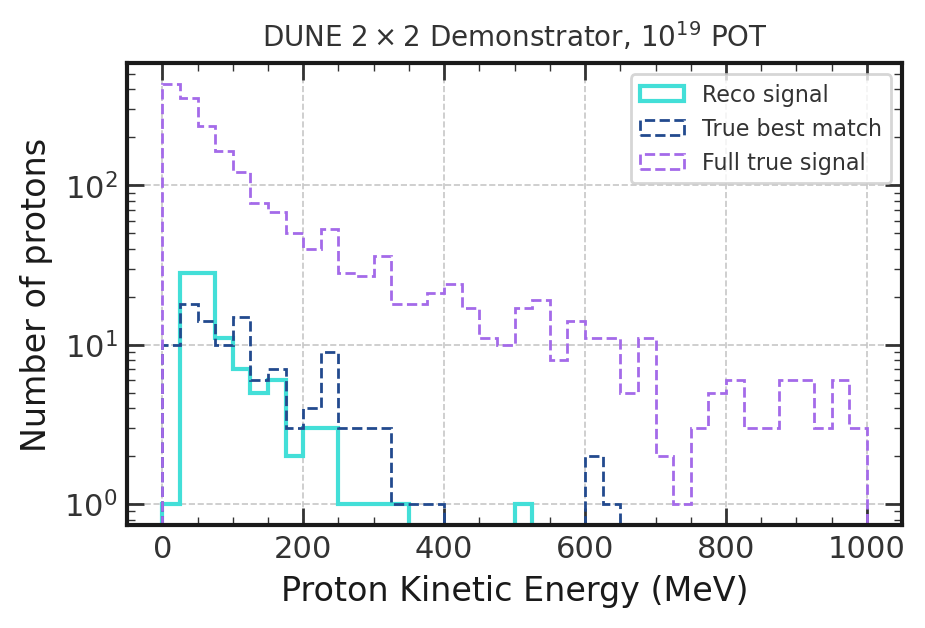

In [24]:
E_mev_bm_proton = [energy * 1000 for energy in E_bm_proton]
K_mev_reco_proton = [energy * 1000 for energy in E_reco_proton] #spine returns K 
E_mev_proton = [energy * 1000 for energy in E_proton]

K_proton_bm= [x - pdg_tab.proton_mass for x in E_mev_bm_proton]
K_proton= [x - pdg_tab.proton_mass for x in E_mev_proton]


plt.hist(K_mev_reco_proton,bins=40,histtype='step', range=[0,1000], color='#43dfd8', linewidth=1.5,label=r'Reco signal')
plt.hist(K_proton_bm,bins=40,histtype='step',range=[0,1000], color='#224a8e', linewidth=1, linestyle='--',label=r'True best match')
plt.hist(K_proton,bins=40,histtype='step',range=[0,1000], color='#a46ae9', linewidth=1, linestyle='--',label=r'Full true signal')
plt.xlabel('Proton Kinetic Energy (MeV)')
plt.ylabel('Number of protons')
# plt.title('DUNE 2X2 CAF - True Signal')
plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT', fontsize = '10')
plt.legend(loc='upper right', fontsize='8') 
plt.show()

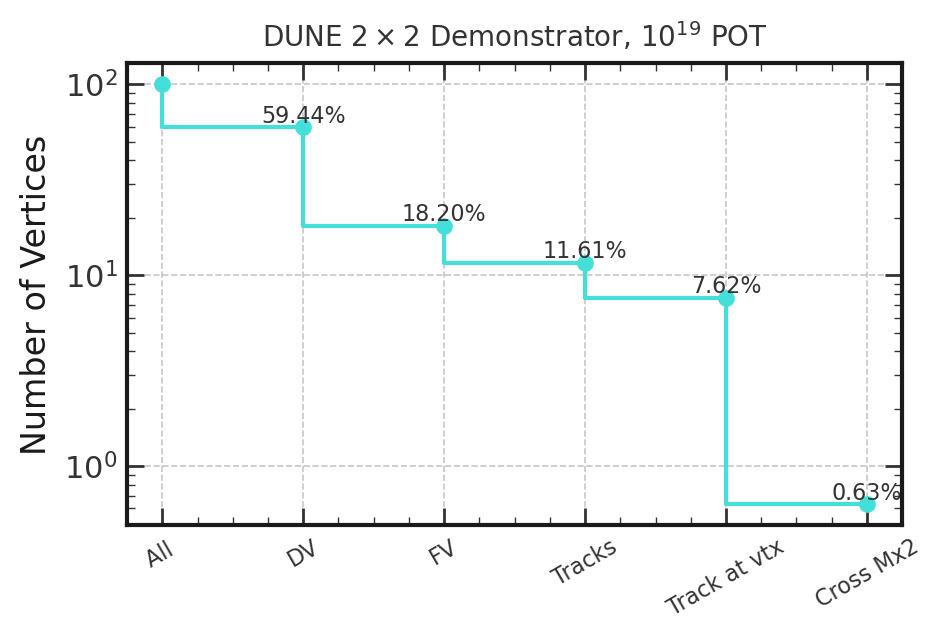

,Cut,Eventss,Percent (%)
0,Total Simulation,260322,100.000000
1,Detector Volume (DV),154740,59.441768
2,Fiducial Volume (FV),47377,18.199384
3,Fiducial Volume track,30230,11.612541
4,Track on vtx,19847,7.624019
5,Mx2,1642,0.630757


In [363]:
reco_color = '#43dfd8'
bm_color = '#224a8e'
fulltrue_color ='#a46ae9'
n_vtx_total=np.sum(df['rec.common.ixn.dlp..length'])
portions=[n_vtx_total,  num_neutrinos_dv_r ,num_neutrinos_fv_r ,  num_track_fv, num_track_vtx_fv,  num_track_Mx2_fv]/((0.01*n_vtx_total))
positions = [0,1,2,3,4,5]
plt.step(positions,portions,marker='o', color=reco_color,label='Spine')

plt.xticks(positions,[r'All ', r'DV', r'FV', r'Tracks', r'Track at vtx', r'Cross Mx2'  ],rotation=30, fontsize ='8')
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT', fontsize = '10')

plt.ylabel('Number of Vertices')
#plt.legend()
plt.show()

data = {
    'Cut': ['Total Simulation', 'Detector Volume (DV)', 
               'Fiducial Volume (FV)', 
               'Fiducial Volume track', 'Track on vtx', 'Mx2'],
    'Eventss': [n_vtx_total,  num_neutrinos_dv_r ,num_neutrinos_fv_r ,  num_track_fv, num_track_vtx_fv, num_track_Mx2_fv],
    'Percent (%)': portions
}

# Creating the DataFrame with the metric names as rows
df_table_with_names = pd.DataFrame(data)
df_table_with_names

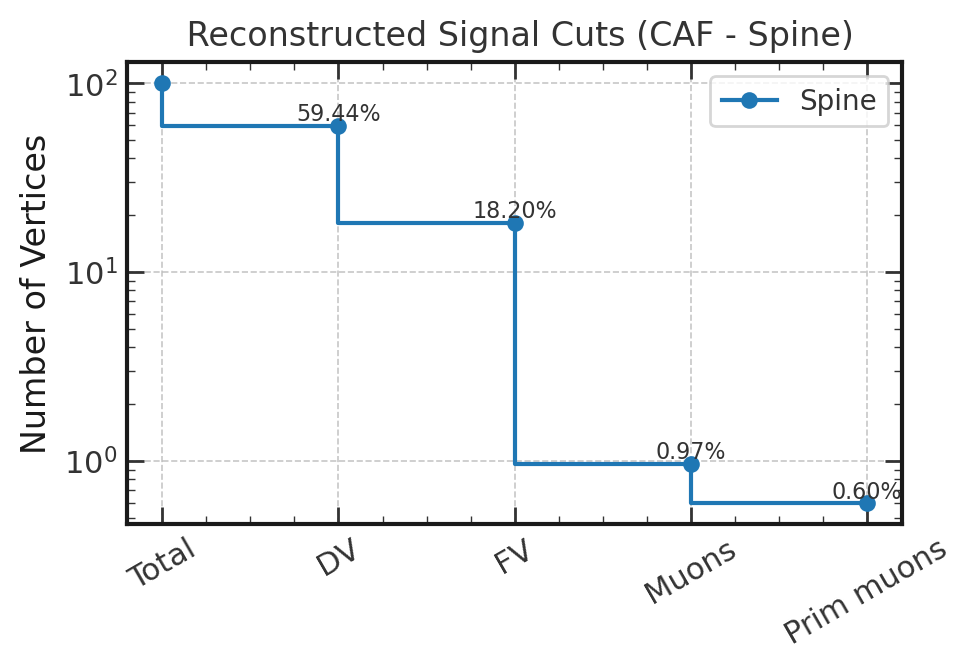

,Cut,Eventss,Percent (%)
0,Total Simulation,260322,100.000000
1,Detector Volume (DV),154740,59.441768
2,Fiducial Volume (FV),47377,18.199384
3,FV Muon,2525,0.969953
4,FV Prim Muon,1556,0.597721


In [197]:
count=np.sum(df['rec.common.ixn.dlp..length'])
portions=[count/(0.01*count),  num_neutrinos_dv_r/(0.01*count),  num_neutrinos_fv_r/(0.01*count),  num_neutrinos_muon_fv/(0.01*count), num_neutrinos_prim_mu_fv/(0.01*count)]
positions = [0,1,2,3,4]
plt.step(positions,portions,marker='o',label='Spine')

plt.xticks(positions,[r'Total', r'DV', r'FV', r'Muons' , r'Prim muons' ],rotation=30)
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
plt.yscale('log')
plt.title(' Reconstructed Signal Cuts (CAF - Spine)')
plt.ylabel('Number of Vertices')
plt.legend()
plt.show()

data = {
    'Cut': ['Total Simulation', 'Detector Volume (DV)', 
               'Fiducial Volume (FV)', 
               'FV Muon',
               'FV Prim Muon'],
    'Eventss': [count,  num_neutrinos_dv_r,  num_neutrinos_fv_r,  num_neutrinos_muon_fv, num_neutrinos_prim_mu_fv],
    'Percent (%)': portions
}

# Creating the DataFrame with the metric names as rows
df_table_with_names = pd.DataFrame(data)
df_table_with_names

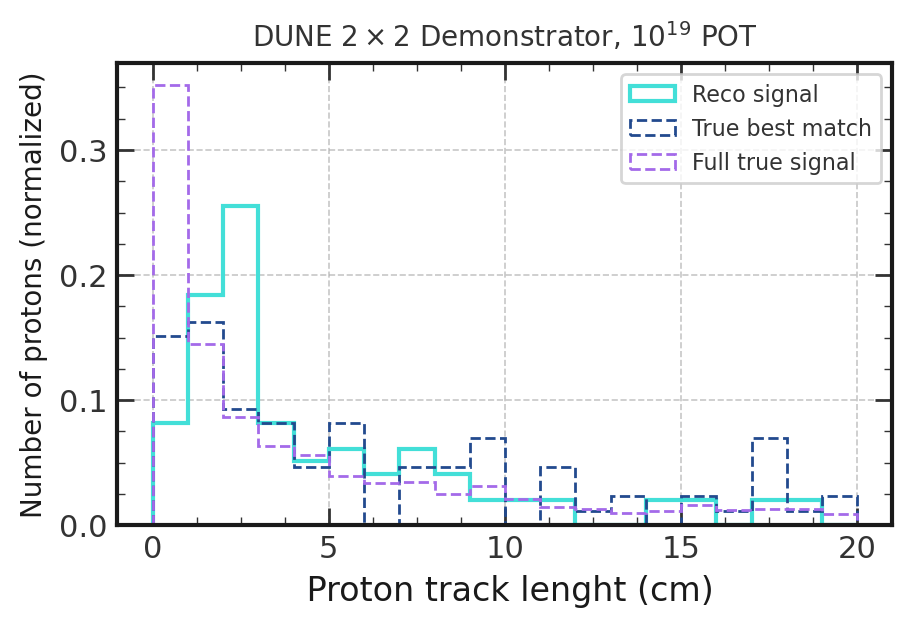

In [27]:
plt.hist(track_lenghts_reco,bins=20,histtype='step', range=[0,20], color='#43dfd8', linewidth=1.5,density=True,label=r'Reco signal')
plt.hist(track_lenghts_match_truth,bins=20,histtype='step',range=[0,20], color='#224a8e',linestyle='--', density=True,linewidth=1,label=r'True best match')
plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
plt.xlabel(' Proton track lenght (cm)')
plt.ylabel('Number of protons (normalized)', fontsize='10')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.legend(loc='upper right', fontsize='8') 
plt.show()

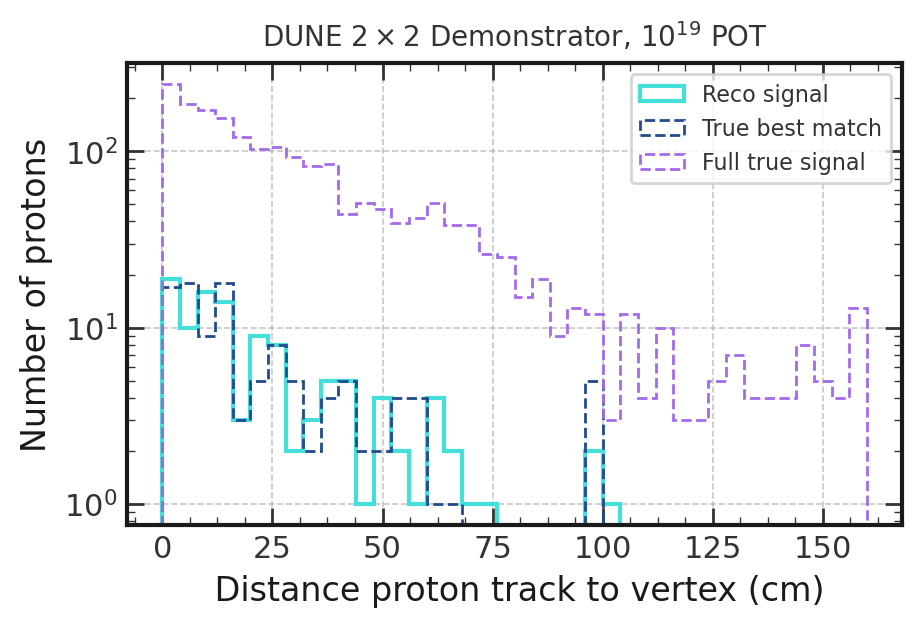

In [26]:
plt.hist(vtx_distances_reco,bins=40,histtype='step', range=[0,160], color='#43dfd8',linewidth=1.5,label=r'Reco signal')
plt.hist(vtx_distances_match_truth,bins=40,histtype='step',range=[0,160], color='#224a8e',linestyle='--', linewidth=1, label=r'True best match')
plt.hist(track_vtx_distances,bins=40,histtype='step',range=[0,160], color='#a46ae9',linewidth=1,linestyle='--', label=r'Full true signal')
# plt.title('DUNE 2x2 CAF')
plt.xlabel(' Distance proton track to vertex (cm)')
plt.ylabel('Number of protons')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.legend(loc='upper right', fontsize='8') 
plt.yscale('log')
plt.show()

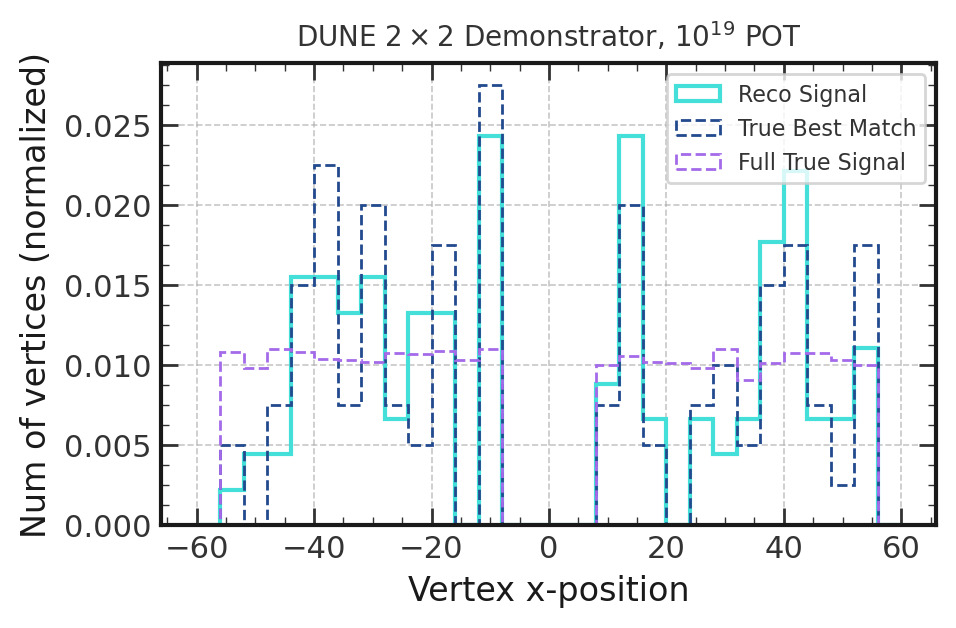

In [369]:
reco_color = '#43dfd8'
bm_color = '#224a8e'
fulltrue_color ='#a46ae9'
# Create a figure and a set of subplots in a 1x3 layout
# fig, axs = plt.plot( figsize=(18, 6))
# Plot the first histogram (vx-position)

plt.hist(vtx_x_candidates, bins=30, histtype='step', range=[-60, 60], color=reco_color,density = True,linewidth=1.5,  linestyle='-',label=r'Reco Signal')
plt.hist(vtx_x_bmcandidates, bins=30, histtype='step', range=[-60, 60], color=bm_color, density = True, linewidth=1, linestyle='--',label=r'True Best Match')
plt.hist(vx_t, bins=30, histtype='step', range=[-60, 60], color=fulltrue_color ,  linestyle='--', linewidth=1, density = True,label=r'Full True Signal')
plt.xlabel('Vertex x-position')
plt.ylabel('Num of vertices (normalized)')
#axs[0].set_yscale('log')plt.legend(loc='upper right', fontsize='8') 
#plt.yscale('log')
plt.legend(loc = 'upper right', fontsize=8)
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')

# Show the plot
plt.show()

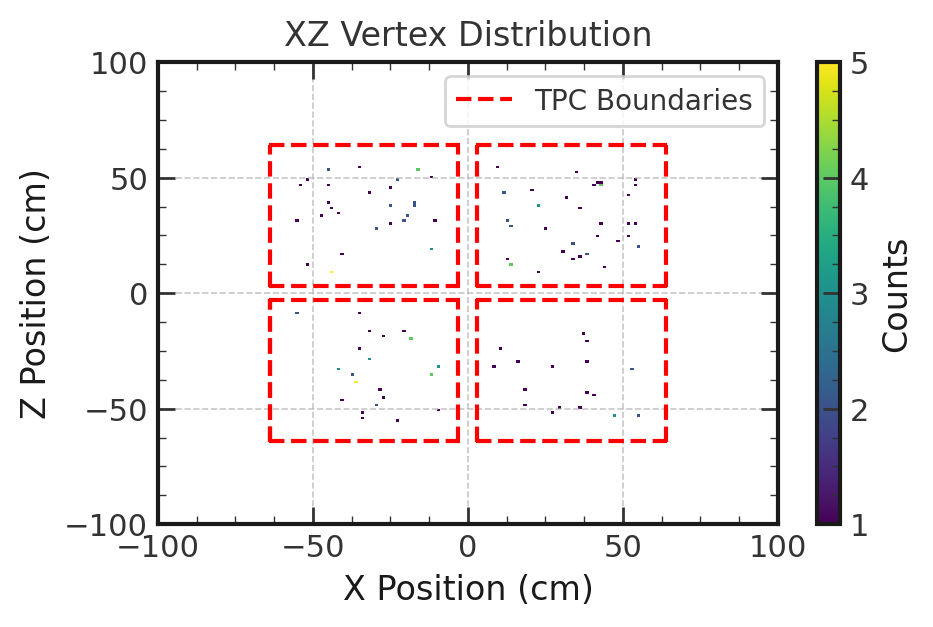

In [ ]:
plt.hist2d(vtx_x_candidates, vtx_z_candidates, bins=100, cmap='viridis', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['x'][1], 'r--')
    plt.plot(traces_anode[i]['x'][1], traces_anode[i]['z'][1], 'r--')
plt.plot(traces_anode[0]['x'][1], traces_anode[0]['z'][1],'r--',label='TPC Boundaries')
plt.title('XZ Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()

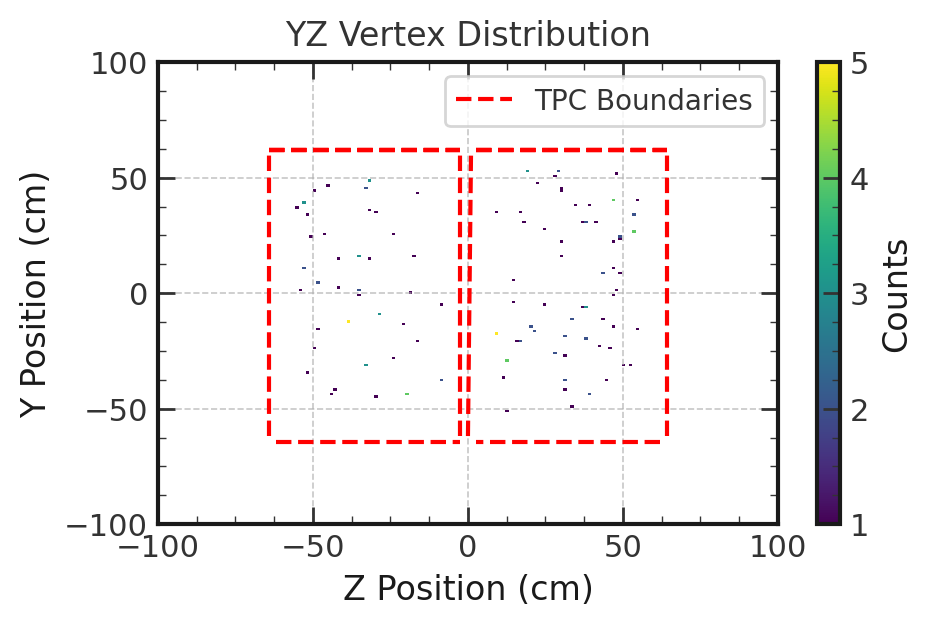

In [ ]:
plt.hist2d(vtx_z_candidates, vtx_y_candidates, bins=100, cmap='viridis', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['y'][1], 'r--')
#     plt.plot(traces_anode[i]['y'][1], traces_anode[i]['z'][1], 'r--')
plt.plot([-traces_anode[0]['y'][1][1], traces_anode[0]['y'][1][1]],'r--',label='TPC Boundaries')
plt.plot([-64.3163,-64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([64.3163,64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([-2.6837,-2.6837 ],[-61.8543,61.8543], 'r--')
plt.plot([-61.8543,-2.6837], [-64.3163,-64.3163 ],'r--')
plt.plot([61.8543,2.6837], [-64.3163,-64.3163 ],'r--')
plt.title('YZ Vertex Distribution')
plt.xlabel('Z Position (cm)')
plt.ylabel('Y Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()

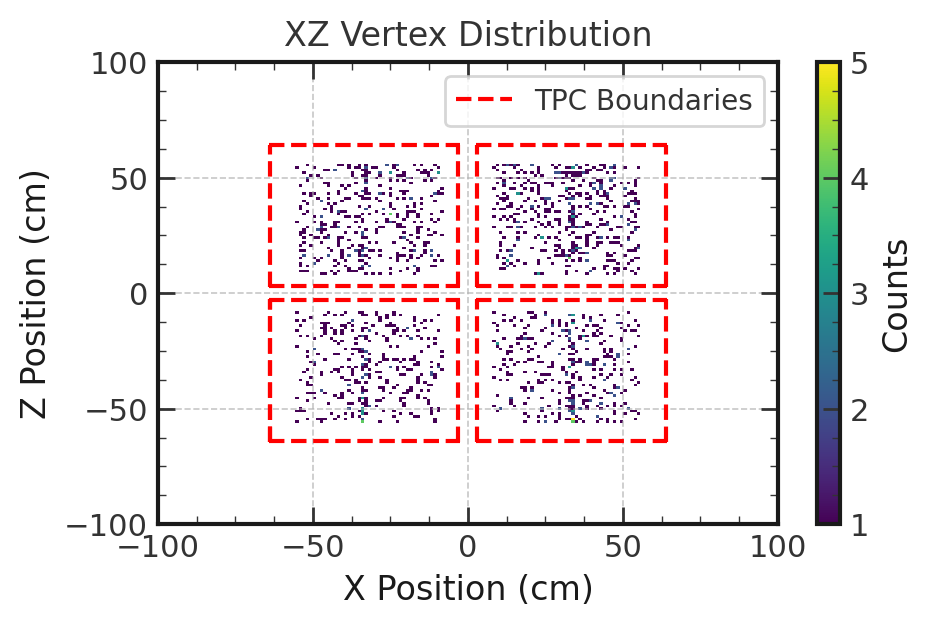

In [ ]:
plt.hist2d(vtx_x_signal, vtx_z_signal, bins=100, cmap='viridis', cmin=0.01)
for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['x'][1], 'r--')
    plt.plot(traces_anode[i]['x'][1], traces_anode[i]['z'][1], 'r--')
plt.plot(traces_anode[0]['x'][1], traces_anode[0]['z'][1],'r--',label='TPC Boundaries')
plt.title('XZ Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.legend()

In [ ]:
#cut: require a reco vtx to produce a reco track 
#cut: require reco vtx to produce track that exit 2x2 downstream
def track_selection_signal(ev_data, ev):

    x_start_track  = ev_data['rec.nd.lar.dlp.tracks.start.x']
    y_start_track = ev_data['rec.nd.lar.dlp.tracks.start.y']
    z_start_track = ev_data['rec.nd.lar.dlp.tracks.start.z']
    z_end_track = ev_data['rec.nd.lar.dlp.tracks.end.z']

    x_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.x']
    y_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.y']
    z_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.z']


    # Stack the coordinates into a single 2D array
    position_vtx = np.vstack((x_coords_vtx, y_coords_vtx, z_coords_vtx)).T
    start_track = np.vstack((x_start_track, y_start_track, z_start_track)).T

    track_on_vtx = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):

        n_reco_tracks = ev_data['rec.nd.lar.dlp.tracks..length'][vtx]
        n_pre = np.sum(ev_data['rec.nd.lar.dlp.tracks..length'][:vtx]) if vtx > 0 else 0
        
        vertex_position = position_vtx[vtx]
        # Scan over particles associated with this interaction
        found_match = False
        
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if np.array_equal(vertex_position, start_track[ip]):
                found_match = True
                #if the track is found, then check if the track also goes out the boundary
                if (z_end_track[ip] >= zbound):
                    track_out[vtx] = True
                    break 
        track_on_vtx[vtx] = found_match
    
    return track_on_vtx,  track_out

In [11]:
def was_neutron_induced_anything(ev_data, vtx_t, proton_parent_id):
    #iterates over primaries to find parent
    neutron_induced = False
    n_prim =ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t >0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced=True
    return neutron_induced 

In [16]:
def was_neutron_induced_any(ev_data, vtx_t, proton_parent_id):
    #iterates over primaries to find parent
    neutron_induced = False
    n_prim =ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t >0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            #ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced=True
    return neutron_induced 

In [27]:
num_prim=0 #all prim neutrons
ninduced_secondary = 0 
n_maskprim=0
secondary_n=0
n=0
track_ids_nn=[]
secondary_p=0
secondary_photon=0
for ev in range(len(df)):
    ev_data=df.iloc[ev]
     #------------------------ true masks -----------
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )

    for vtx, bool_value in enumerate(mask_fv_Ar):
        if bool_value==False: continue
        else: 
            num_prim += np.sum(ev_data['rec.mc.nu.nprim'])
            for id in ev_data['rec.mc.nu.sec.parent']:
                if id not in track_ids_nn: 
                    induced_or_not = was_neutron_induced_anything(ev_data, vtx, id) 
                    if induced_or_not:
                        track_ids_nn.append(id)
                        ninduced_secondary +=1
                else: continue
                    
            sec_neutrons_mask = ([ev_data['rec.mc.nu.sec.pdg']==pdg_tab.neutron])
            #if id in  
            n_mask = (ev_data['rec.mc.nu.prim.pdg'] == pdg_tab.neutron)
            n_maskprim += np.sum(n_mask)
            #prim neutrons with E above tens of Mevs
            
            for idn,val in enumerate(ev_data['rec.mc.nu.sec.pdg']==pdg_tab.neutron): 
                if val:
                    id_parent = ev_data['rec.mc.nu.sec.parent'][idn]
                    n_induced_or_not = was_neutron_induced_anything(ev_data, vtx, id_parent) 
                    if n_induced_or_not:
                        secondary_n +=1

            for idn,val in enumerate(ev_data['rec.mc.nu.sec.pdg']==pdg_tab.proton): 
                if val:
                    id_parent = ev_data['rec.mc.nu.sec.parent'][idn]
                    n_induced_or_not = was_neutron_induced_anything(ev_data, vtx, id_parent) 
                    if n_induced_or_not:
                        secondary_p +=1
            for idn,val in enumerate(ev_data['rec.mc.nu.sec.pdg']==pdg_tab.photon): 
                if val:
                    id_parent = ev_data['rec.mc.nu.sec.parent'][idn]
                    p_induced_or_not = was_neutron_induced_anything(ev_data, vtx, id_parent) 
                    if n_induced_or_not:
                        secondary_photon +=1
            #print(induced_or_not)




In [29]:
print(f'total prim particles in signal: {num_prim}')
print(f'total prim neutrons in signal: {n_maskprim}')
print(f'neutrons that produced a secondary particle: {ninduced_secondary}')
print(f'nprim that produce neutrons: {secondary_n}')
print(f'nprim that produce protons: {secondary_p}')
print(f'nprim that produce photons: {secondary_photon}')





total prim particles in signal: 421024
total prim neutrons in signal: 124579
neutrons that produced a secondary particle: 33
nprim that produce neutrons: 2861
nprim that produce protons: 5447
nprim that produce photons: 9056


In [80]:
def find_best_match(ev_data, ip):   
    #given the index of a reco particle, finds its best match
    truth_length = ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
    max_overlap = 0
    best_match_idx = 0
    best_match_type = 0
    best_match_pdg=None

    for tp in range(truth_pre, truth_pre + truth_length):
        temp_overlap = ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
        temp_tp_match = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
        temp_tp_type = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][tp]  # 1 prim and 3 second
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_idx = temp_tp_match
            best_match_type = temp_tp_type

    if(best_match_type==3):
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][best_match_idx]
    elif(best_match_type==1):
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][best_match_idx]

    # Find the vertex where the best match index belongs in truth
    vtx_t = None
    for i in range(len(ev_data['rec.mc.nu.sec..length'])):
        p_in_vtx = np.sum(ev_data['rec.mc.nu.sec..length'][:i+1])  # Include the current vertex
        if best_match_idx < p_in_vtx:
            vtx_t = i
            break
        else: continue
    return best_match_idx, best_match_type, best_match_pdg, vtx_t, max_overlap

In [73]:
idx =8
best_match_type, best_match_pdg, idx, vtx_t, (ev_data['rec.mc.nu.sec..length'])

(1, 2212, 8, 7, array([ 8,  0, 11,  0,  1,  0,  1,  0], dtype=int32))

In [79]:
for i in range(len(ev_data['rec.mc.nu.sec..length'])):
        p_in_vtx = np.sum(ev_data['rec.mc.nu.sec..length'][:i+1])
        print(f'there are {p_in_vtx} particles up to the vtx {i}')  # Include the current vertex
        if idx < p_in_vtx:
            vtx_t = i
            print(vtx_t)
            break
        else: continue
            #break

there are 8 particles up to the vtx 0
there are 8 particles up to the vtx 1
there are 19 particles up to the vtx 2
2


In [179]:
idx= 10
n_vtxr = 2
n_vtxt = 4
ev= 1986
ev_check = df.iloc[ev]
print(f'event {ev}')
print(f'Particles per vertex {ev_check['rec.common.ixn.dlp.part.dlp..length']}')
print(f'reco particle {idx} is a {ev_check['rec.common.ixn.dlp.part.dlp.pdg'][idx]}')
ev_check['rec.common.ixn.dlp.part.dlp..length'][n_vtxr]
reco_backtrack(ev_check, n_vtxr)

event 1986
Particles per vertex [2 4 6 1]
reco particle 10 is a 2212
Number of interactions in this event  4
Printing info for interaction  2
This interaction has 6 reco particles
Particle 11 is a 13 primary


In [255]:
def reco_backtrackk(df_test,ixn_index, ev):
    vtx_t=None
    best_match_pdg = None
    best_match_type = None
    best_match_idx = None
    
    r_ixn = len(df_test['rec.common.ixn.dlp.id'])
    n_particles = df_test['rec.common.ixn.dlp.part.dlp..length'][ixn_index]
    if(ixn_index==0):
        n_pre = 0
    else: 
        n_pre = np.sum(df_test['rec.common.ixn.dlp.part.dlp..length'][:ixn_index]) 

    # Scan over particles associated to this ixn 
    for ip in range(n_pre,n_pre + n_particles):
        #print(ip)
        # Check if particle is primary 
        is_primary = df_test['rec.common.ixn.dlp.part.dlp.primary'][ip]
        if(is_primary==False):
            continue 
        else:
            # Get reco PDG
            reco_pdg = df_test['rec.common.ixn.dlp.part.dlp.pdg'][ip]
            #print(f"Particle {ip} is a {reco_pdg} primary")
            if(reco_pdg==2212):
                truth_length = df_test['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
                truth_pre = np.sum(df_test['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
                #print(f'With {truth_length} overlapping particles')
                max_overlap = 0
                best_match_idx = 0
                best_match_type = 0
                # Need to do the same trick as for scan over reco particles
                for tp in range(truth_pre,truth_pre+truth_length):
                    temp_overlap = df_test['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
                    temp_tp_match = df_test['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
                    temp_tp_type = df_test['rec.common.ixn.dlp.part.dlp.truth.type'][tp] # 1 prim and 3 second
                    #print(f'True ({temp_tp_type}) particle {temp_tp_match} has this amount of overlap {temp_overlap}')
                    if(temp_overlap>max_overlap):
                        max_overlap=temp_overlap
                        best_match_idx=temp_tp_match
                        best_match_type=temp_tp_type


                if(best_match_type==3):
                    best_match_pdg = df_test['rec.mc.nu.sec.pdg'][best_match_idx]
                    #print('true secondary, PDG of best match: ', best_match_pdg, best_match_type, best_match_idx, ev)
                    for i in range(len(df_test['rec.mc.nu.sec..length'])):
                        if best_match_idx < np.sum(df_test['rec.mc.nu.sec..length'][:i+1]):
                            vtx_t = i
                            #print(f'vertex: {vtx_t}')
                            break
                        else: continue
                    
                elif(best_match_type==1):
                    best_match_pdg = df_test['rec.mc.nu.prim.pdg'][best_match_idx]
        
                    #print('true primary, PDG of best match: ', best_match_pdg, best_match_type,best_match_idx,ev)
                    for i in range(len(df_test['rec.mc.nu.prim..length'])):
                        if best_match_idx < np.sum(df_test['rec.mc.nu.prim..length'][:i+1]):
                            vtx_t = i
                            #print(f'vertex: {vtx_t}')
                            break
                        else: continue

    return best_match_pdg, best_match_type, best_match_idx, vtx_t, r_ixn


In [188]:
ev_check=df.iloc[ev]
reco_backtrackk(ev_check, 2)

Number of interactions in this event  4
Printing info for interaction  2
This interaction has 6 reco particles
Particle 11 is a 13 primary


In [250]:
best_match_pdg, best_match_type, best_match_idx, vtx_t, r_ixn

(None, None, None, None, 5)

In [168]:
ev_check['rec.mc.nu.prim.pdg']

array([  22,  -13, 2112, 2112,  111,  211, 2112,   13, 2212,  211,   22,
        -13, 2212, 2112,  -13, 2212, -211,  -14,  111, 2212, 2212, 2112,
       -211, 2212], dtype=int32)

In [262]:
#store num reco vtx for the cuts
num_neutrinos_dv_r=0 # in dv
num_neutrinos_fv_r=0 # in fv
num_neutrinos_muons = 0 #produced reco muon
num_neutrinos_muon_fv = 0 #produced reco muon in fv
num_neutrinos_prim_mu_fv=0 #produced prim muon in fv
#for tracks
num_track_fv = 0 # produced a track in fv
num_track_vtx_fv =0 #produced track that stat on vtx
num_track_vtx_out_fv=0 #produced track start on vtx and exit 2x2 downstream
num_track_Mx2_fv = 0 #num of tracks that crossed minerva 


reco_sec_proton=0
reco_primproton_with_bm_sec_proton  =0
reco_prim_proton =0
candidate_not_in_signal=0
candidate_in_signal =0 
count_sec =0

#store track length and distance to vtx 
track_lenghts_match_truth = [] #true particles best match 
vtx_distances_match_truth =[]  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#positions of the vtx that passed the reco signal cuts
vtx_x_signal=[]
vtx_y_signal=[]
vtx_z_signal=[]
#positions of the vtx the reco candidates
vtx_x_candidates=[]
vtx_y_candidates=[]
vtx_z_candidates=[]

candidate_event_vtx_r = []
candidate_event_vtx_t = []

vtx_x_bmcandidates=[]
vtx_y_bmcandidates=[]
vtx_z_bmcandidates=[]


bmnot_a_proton =[]
bmtrue_prim_proton=[]
bmtrue_intermediate_proton=[]

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': []
}


for ev in range(len(df)):
   # print(ev)
    
    ev_data = df.iloc[ev]
    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    
    
     
    #------------------------ true masks -----------
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )



   #---------Reco masks---------------

    mask_dv_r = (
        (ev_data['rec.common.ixn.dlp.vtx.x'] >= anode_xs[0]) & (ev_data['rec.common.ixn.dlp.vtx.x'] <= anode_xs[3]) &
        (ev_data['rec.common.ixn.dlp.vtx.y'] >= anode_ys[0]) & (ev_data['rec.common.ixn.dlp.vtx.y'] <= anode_ys[1]) &
        (ev_data['rec.common.ixn.dlp.vtx.z'] >= anode_zs[0]) & (ev_data['rec.common.ixn.dlp.vtx.z'] <= anode_zs[3]) 
    )
    
    #mask vertex on the fiducial volume
    mask_fv_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])<zbound-tpc_dist)
    )
    
    num_neutrinos_dv_r += np.sum(mask_dv_r)
    num_neutrinos_fv_r += np.sum(mask_fv_r)
    #signals muons + fv
    signal_fv_muons = signal_definition(ev_data,  pdg_tab.muon, mask_fv_r)  
    num_neutrinos_muon_fv += np.sum(signal_fv_muons) 
    #signal prim muon in fv 
    signal_prim_muon_fv = signal_definition_prim(ev_data,  pdg_tab.muon, mask_fv_r)
    num_neutrinos_prim_mu_fv += np.sum(signal_prim_muon_fv) 
    #signal tracks in fv
    signal_tracks_fv= (ev_data['rec.nd.lar.dlp.tracks..length'] != 0) & (mask_fv_r)
    num_track_fv += np.sum(signal_tracks_fv)
    #get the tracks on vertex
    tracks_vtx, track_vtx_out, tracks_mx2 = track_selection_signal(ev_data,ev)
    tracks_vtx_fv = (tracks_vtx) & (mask_fv_r) #get them now in fv
    tracks_vtx_out_fv = (track_vtx_out) & (mask_fv_r)
    track_Mx2_fv= (track_vtx_out)&(mask_fv_r)
    #track_Mx2_fv = (track_Mx2) & (mask_fv_r)
    num_track_vtx_fv += np.sum(tracks_vtx_fv)
    num_track_vtx_out_fv += np.sum(tracks_vtx_out_fv)
    num_track_Mx2_fv += np.sum(track_Mx2_fv)

    # test_muon_track = [[reco_sx,reco_sy,reco_sz],[reco_ex,reco_ey,reco_ez]]
    # bm, overlap, dx, dy, exit_minerva = Mx2_DS_Match(test_muon_track,minerva_data)

    for vtx_r, value in enumerate(tracks_vtx_out_fv):
        if value == True:

            best_match_pdg, best_match_type, best_match_idx, vtx_t, r_ixn =  reco_backtrackk(ev_data, vtx_r, ev)
            
            if (best_match_pdg!= None) and  (best_match_type!= None) and (best_match_idx!= None) and (vtx_t != None):
                reco_proton_dic['best_match_pdg'].append(best_match_pdg)
                reco_proton_dic['best_match_idx'].append(best_match_idx)
                reco_proton_dic['best_match_type'].append(best_match_type)
                reco_proton_dic['vtx_t'].append(vtx_t)
                reco_proton_dic['reco_inx'].append(r_ixn)
                reco_proton_dic['ev'].append(ev)
                

            # n_reco_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx_r]
            # n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx_r]) if vtx_r>0 else 0
            
            # #store info of the vertices that passsed the cuts
            # vtx_x_signal.append(ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r])
            # vtx_y_signal.append(ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r])
            # vtx_z_signal.append(ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r])
            

            # # Scan over particles associated with this ixn 
            # for ip in range(n_pre, n_pre + n_reco_particles):
            #     if (
            #         ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] == 0 and
            #         ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip] == pdg_tab.proton 
            #     ): 
            #         reco_sec_proton+=1
            #         #if the particle was reco sec proton, find best match
            #         best_match_idx, best_match_type, best_match_pdg, vtx_t, max_overlap = find_best_match(ev_data,ip)
            #         if (best_match_pdg == pdg_tab.proton and best_match_type == 3):
            #             count_sec+=1
            #             #if best match is also sec proton, check if parent is neutron
            #             proton_parent_id = ev_data['rec.mc.nu.sec.parent'][best_match_idx]
            #             neutron_induced=was_neutron_induced(ev_data,vtx_t, proton_parent_id)
    
            #             if neutron_induced == True: 
            #                 candidate_not_in_signal +=1
                          
                            # if ev_data['rec.mc.nu.E'][vtx_t] in ev_data['rec.mc.nu.E'][mask_signal]:
                            #     match_truth_data = get_match_truth_data(ev_data, vtx_t, best_match_idx)
                            #     track_lenghts_match_truth.append(match_truth_data['track_length_truth'])
                            #     vtx_distances_match_truth.append(match_truth_data['vtx_distance_truth'])
                            #     #reco tracks
                            #     match_reco_data = get_match_reco_data(ev_data, vtx_r,ip)
                            #     track_lenghts_reco.append(match_reco_data['track_length_reco'])
                            #     vtx_distances_reco.append(match_reco_data['vtx_distance_reco'])
                            #     #store position of the vertices of the candidaes
                            #     vtx_x_candidates.append(ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r])
                            #     vtx_y_candidates.append(ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r])
                            #     vtx_z_candidates.append(ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r])
                            #     vtx_x_bmcandidates.append(ev_data['rec.mc.nu.vtx.x'][vtx_t])
                            #     vtx_y_bmcandidates.append(ev_data['rec.mc.nu.vtx.x'][vtx_t])
                            #     vtx_z_bmcandidates.append(ev_data['rec.mc.nu.vtx.x'][vtx_t])
                            #     candidate_event_vtx_r.append(np.array([ev, vtx_r]))
                            #     candidate_event_vtx_t.append(np.array([ev, vtx_t]))
                            #     E_bm_proton.append(match_truth_data['E_bestmatch_proton'])
                            #     E_reco_proton.append(match_reco_data['E_proton'])

                    # elif (best_match_pdg == pdg_tab.proton and best_match_type == 1):
                    #     bmtrue_prim_proton.append(ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
                    # elif (best_match_pdg == pdg_tab.proton and best_match_type == 2):
                    #     bmtrue_intermediate_proton.append(ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
#                     elif (best_match_idx !=None) and (best_match_pdg !=None) and (best_match_type !=None) and (vtx_t!= None) : 
# #                        bmnot_a_proton.append(ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
#                         bmnot_a_proton_dic['best_match_idx'].append(best_match_idx)
#                         bmnot_a_proton_dic['best_match_pdg'].append(best_match_pdg)
#                         bmnot_a_proton_dic['vtx_t'].append(vtx_t)
#                         bmnot_a_proton_dic['vtx_r'].append(vtx_r)
#                         bmnot_a_proton_dic['max_overlap'].append(max_overlap)
#                         bmnot_a_proton_dic['ev'].append(ev)
#                         bmnot_a_proton_dic['reco_inx'].append(ip)



                # #look for particles that were tagged as prim proton but had sec proton best match
                # if (
                #     ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] == 1 and
                #     ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip] == pdg_tab.proton 
                # ): 
                    
# print(len(track_lenghts_reco), len(track_lenghts_match_truth))


/tmp/ipykernel_1408751/1074249815.py:191: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/tmp/ipykernel_1408751/1074249815.py:192: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/tmp/ipykernel_1408751/1074249815.py:139: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


In [245]:
ev= 8599
check = df.iloc[ev]
#2212 1 18 8599
best_match_idx  =4
check['rec.mc.nu.prim.pdg'], check['rec.mc.nu.prim..length']


(array([  13, 2212,  211, -211,  111, -211,  211,  -13, 2112, 2112,   22,
         -13, 2212, -211, -211,  -13, 2212, 2212, 2212, 2212, 2212, 2212,
        2212, 2212, 2112, 2112, 2112, 2112, 2112, 2112, 2112, 2112, 2112,
        -211,  211,   22,  -13, 2212, -211,  111, 2212,  -13, 2112, 2112,
         -14, 2112, 2212, 2212,  111, 2112], dtype=int32),
 array([ 7,  3,  5, 20,  6,  3,  6], dtype=int32))

In [227]:
for i in range(len(check['rec.mc.nu.sec..length'])):
    if best_match_idx < np.sum(check['rec.mc.nu.sec..length'][:i+1]):
        vtx = i
        print(vtx)
        break
    else: continue


2


In [287]:
pdgs= np.array(reco_proton_dic['best_match_pdg'])
npdgs=pdgs[pdgs==pdg_tab.neutron] 
ppdgs=pdgs[pdgs==pdg_tab.proton] 
len(npdgs), len(pdgs), len(ppdgs)

idxs= np.array(reco_proton_dic['best_match_idx']) #.append(best_match_idx)
nidxs = idxs[pdgs==pdg_tab.neutron]
                # reco_protonnp_dic['best_match_type'].append(best_match_type)
                # reco_proton_dic['vtx_t'].append(vtx_t)
                # reco_proton_dic['reco_inx'].append(r_ixn)
                # reco_proton_dic['ev'].append(ev)
evs= np.array(reco_proton_dic['ev'])
nevs = evs[pdgs==pdg_tab.neutron]
rinx= np.array(reco_proton_dic['reco_inx'])
nrix = rinx[pdgs==pdg_tab.neutron]
len(pdgs), len(npdgs), len(ppdgs), len(idxs), len(nidxs), len(nevs)
nidxs, nevs, nrix

(array([ 2,  1,  1,  3,  1,  2,  4, 10, 16,  1,  1,  5,  5,  4,  6,  7, 22,
         1,  2,  2,  1,  5,  2,  1,  2,  1,  5,  5,  3,  3,  1,  2,  5,  2,
        16,  2,  2,  3,  4,  1,  4, 11,  1,  3,  1]),
 array([   295,    712,   1152,   5540,  14485,  19160,  19440,  22650,
         23394,  29330,  32705,  33816,  34602,  45930,  52017,  52495,
         53568,  54181,  59991,  63723,  63899,  65435,  70364,  70809,
         74304,  90889,  91744,  94162,  97796,  98460, 108736, 110431,
        111105, 113653, 116748, 128722, 133709, 138833, 142721, 148725,
        155386, 163136, 164402, 167297, 169645]),
 array([2, 4, 3, 4, 4, 2, 3, 3, 6, 2, 4, 3, 6, 3, 5, 4, 6, 2, 3, 2, 3, 2,
        4, 2, 2, 3, 4, 6, 1, 5, 6, 6, 3, 3, 3, 2, 4, 6, 3, 5, 6, 2, 3, 3,
        3]))

In [275]:
ev= 295 
inx_r = 2 #reco particle index 
n_idx = 2 #true particle index

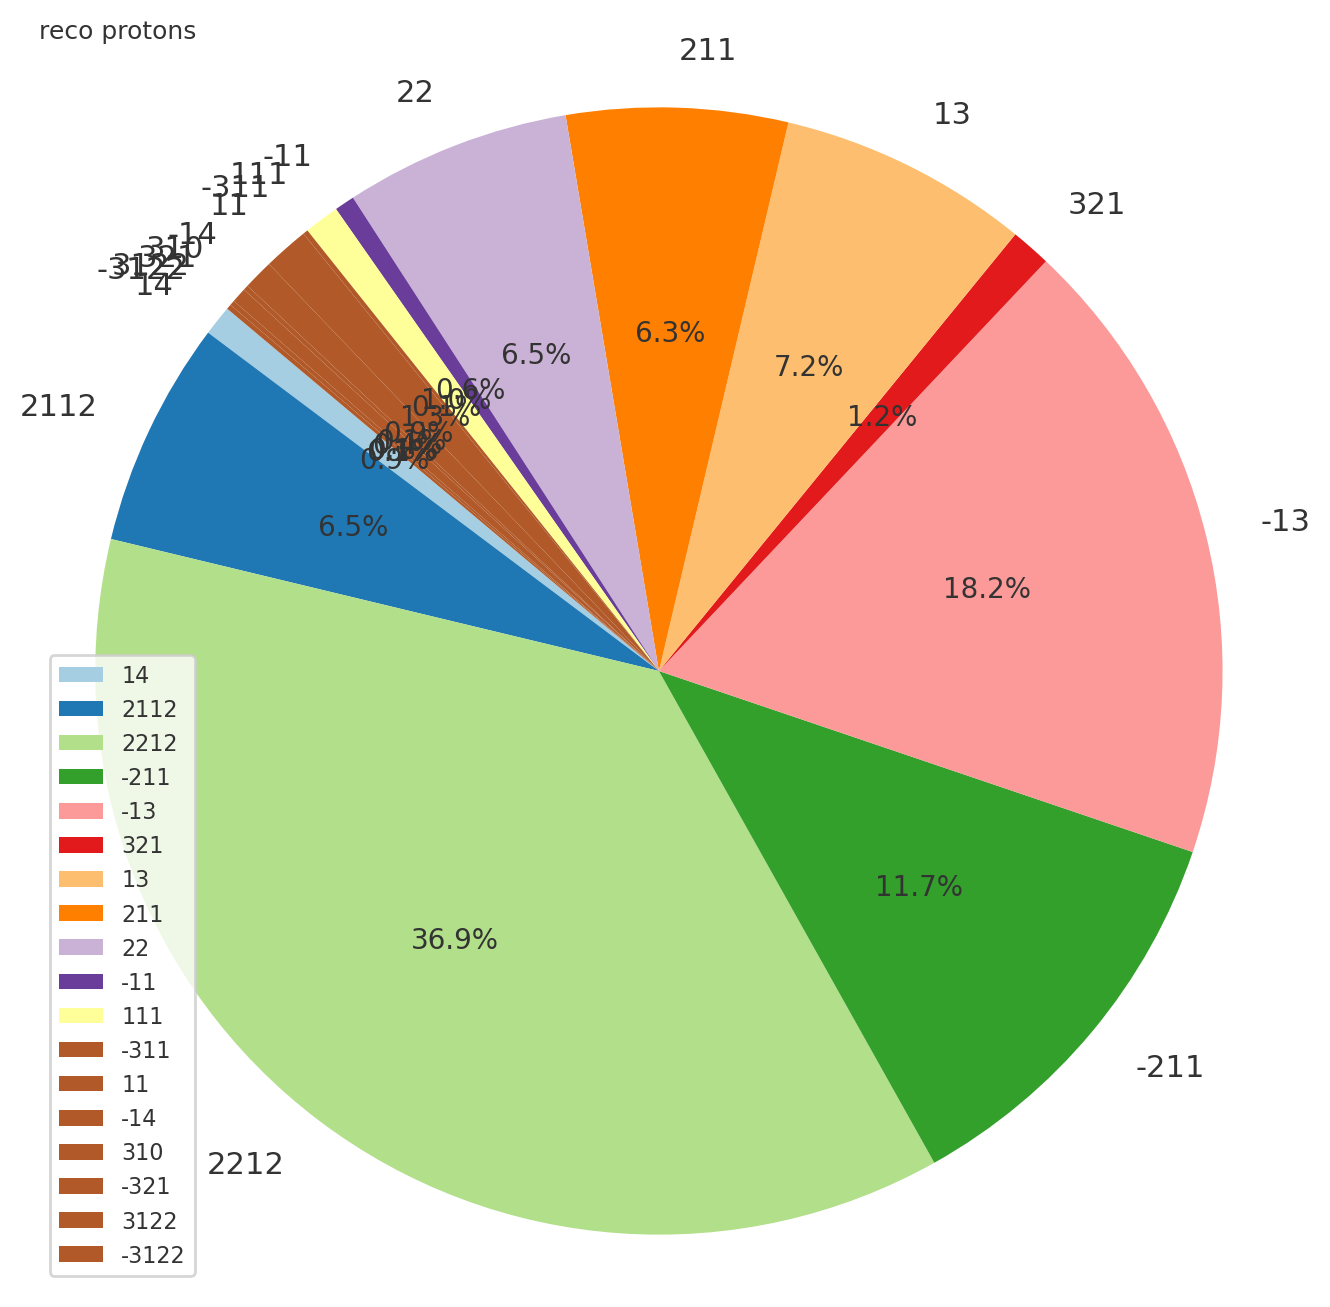

In [269]:
labels = C.keys()
sizes = C.values()
colors = plt.cm.Paired(range(len(labels)))  # Color map for distinct colors

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)#, fontsize=8)
plt.title('reco protons', fontsize=9,loc='left')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(fontsize =8,loc='lower left')
plt.show()

In [267]:
pdg_tab.neutron

2112